In [1]:
import sys
import deepwalk_lesmis as dwlesmis
import numpy as np
from sklearn.cluster import SpectralClustering
from sklearn import preprocessing

In [2]:
def check_method(method):
    val = None
    if method == "kmedoids" or method =="Kmedoids":
        val = "kmedoids"
    elif method =="kmeans" or method == "Kmeans":
        val = "kmeans"
    else:
        sys.exit(f"methodの値が無効です method : {method}")
    return val

In [3]:
def check_data(data):
    data_list = ["football", "polbooks", "karateclub", "lesmis"]
    if data in data_list:
        pass
    else:
    
        sys.exit(f"変数dataの値が無効です data : {data}")

In [4]:
Valjean_lof = []
Marius_lof  = []

        

In [5]:
#実行回数(埋め込み-クラスタリング-ARI)
TIME = 10

data = "lesmis"
check_data(data)

# インプットするグラフ生成とラベルの取得(ラベルなしデータはNone)
INPUT, TRUE_LABEL = dwlesmis.generate_Graph("lesmis")

#インプットするグラフが無向グラフかどうか(True:無向グラフ,　False:有向グラフ)
UNDIRECTED = True




# １ノードあたりの実行数
NUMBER_WALKS =100

# 1ウォークあたりの長さ
WALK_LENGTH = 100

# skipgramので使われるウィンドウサイズ
WINDOW_SIZE = 2




# ランダムシード値
SEED = 0

# 埋め込み後の各ノードの次元数
REPRESENTATION_SIZE = 2

# 並列プロセス数
WORKERS = 1

#クラスタ数
N_CLUSTER = 5

#クラスタリング手法
"""
kmedoids : "kmedoids"
kmeans   : "kmeans"
"""
METHOD = check_method("kmeans")

#結果を表示するかどうか
SHOW = False

#注目するノードリスト
ATTENTION_NODE_LIST = ["Valjean","Marius"]

"""
以下はパラメータを変更して連続で実行する際に使用
(for文でリストを与えて実行)

# １ノードあたりの実行数
NUMBER_WALKS_LIST = [1, 2, 4, 6, 8, 10, 15, 20, 25, 30]

# 1ウォークあたりの長さ
WALK_LENGTH_LIST = [5]

# ウィンドウサイズリスト
WINDOW_SIZE_LIST = [1, 2, 3, 4, 5,6,7,8,9,10]
"""

'\n以下はパラメータを変更して連続で実行する際に使用\n(for文でリストを与えて実行)\n\n# １ノードあたりの実行数\nNUMBER_WALKS_LIST = [1, 2, 4, 6, 8, 10, 15, 20, 25, 30]\n\n# 1ウォークあたりの長さ\nWALK_LENGTH_LIST = [5]\n\n# ウィンドウサイズリスト\nWINDOW_SIZE_LIST = [1, 2, 3, 4, 5,6,7,8,9,10]\n'

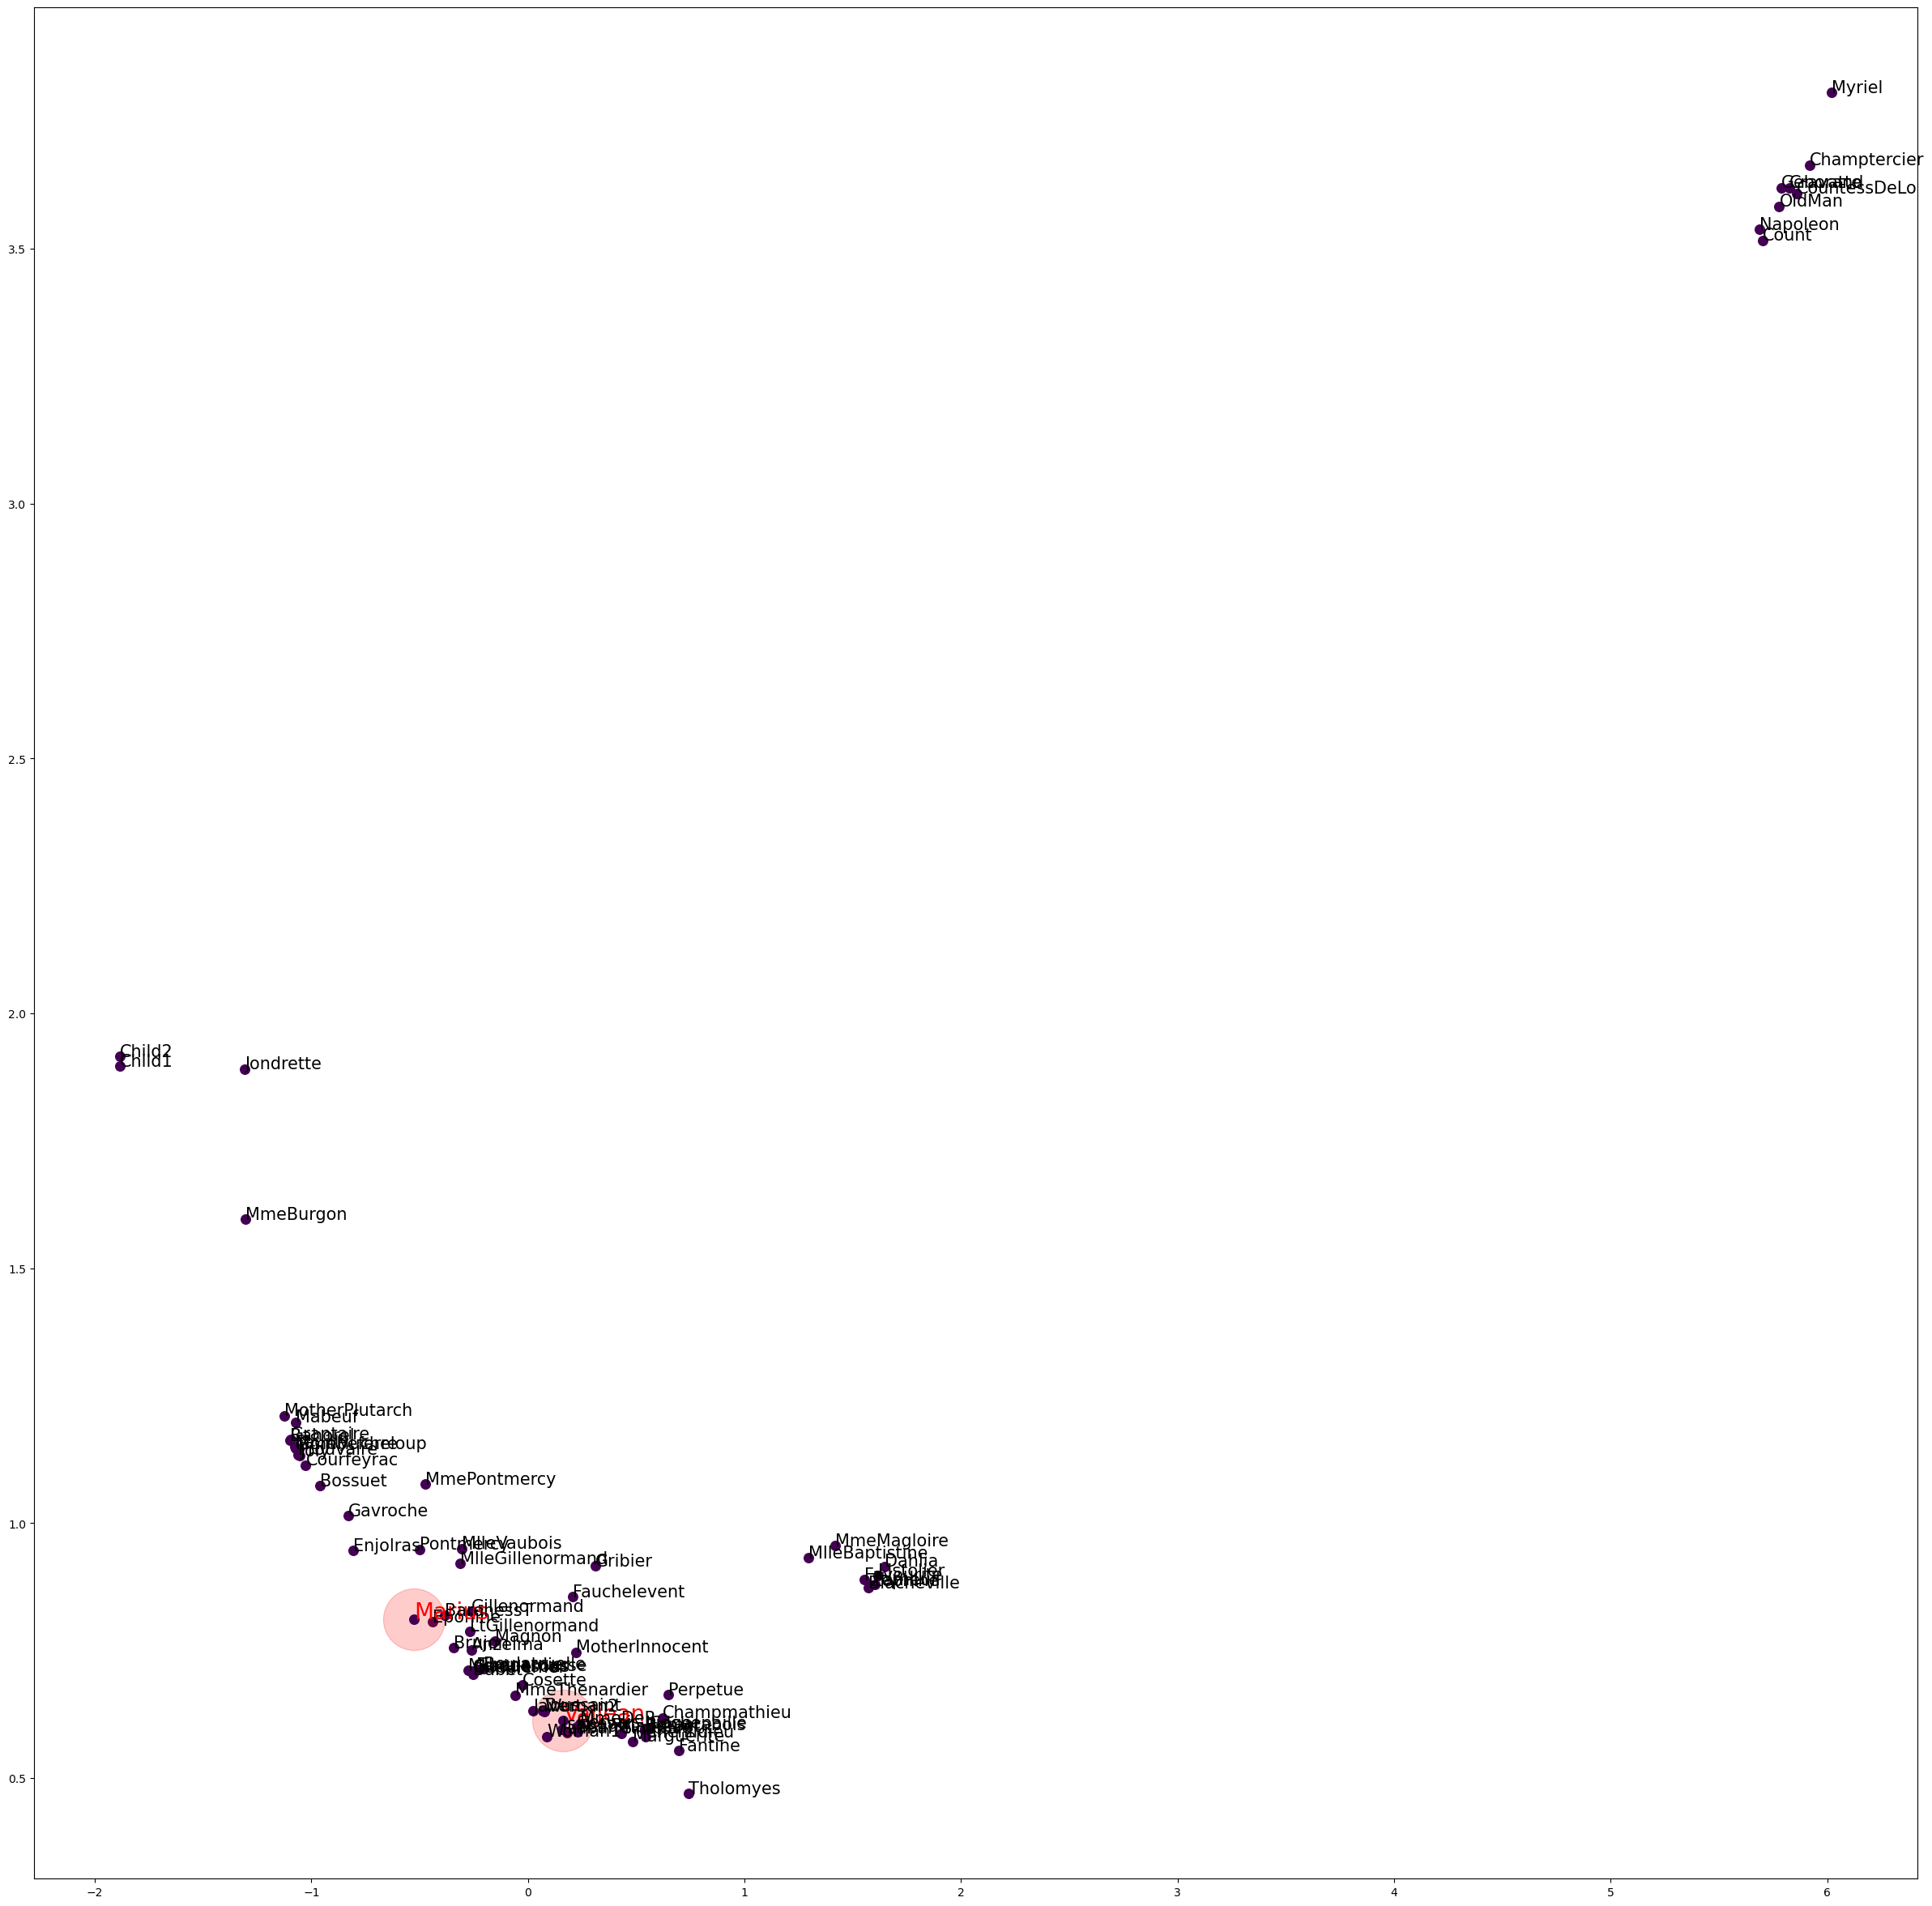

ValjeanのLOF :  0.9593058758189951
MariusのLOF :  1.289970297064423


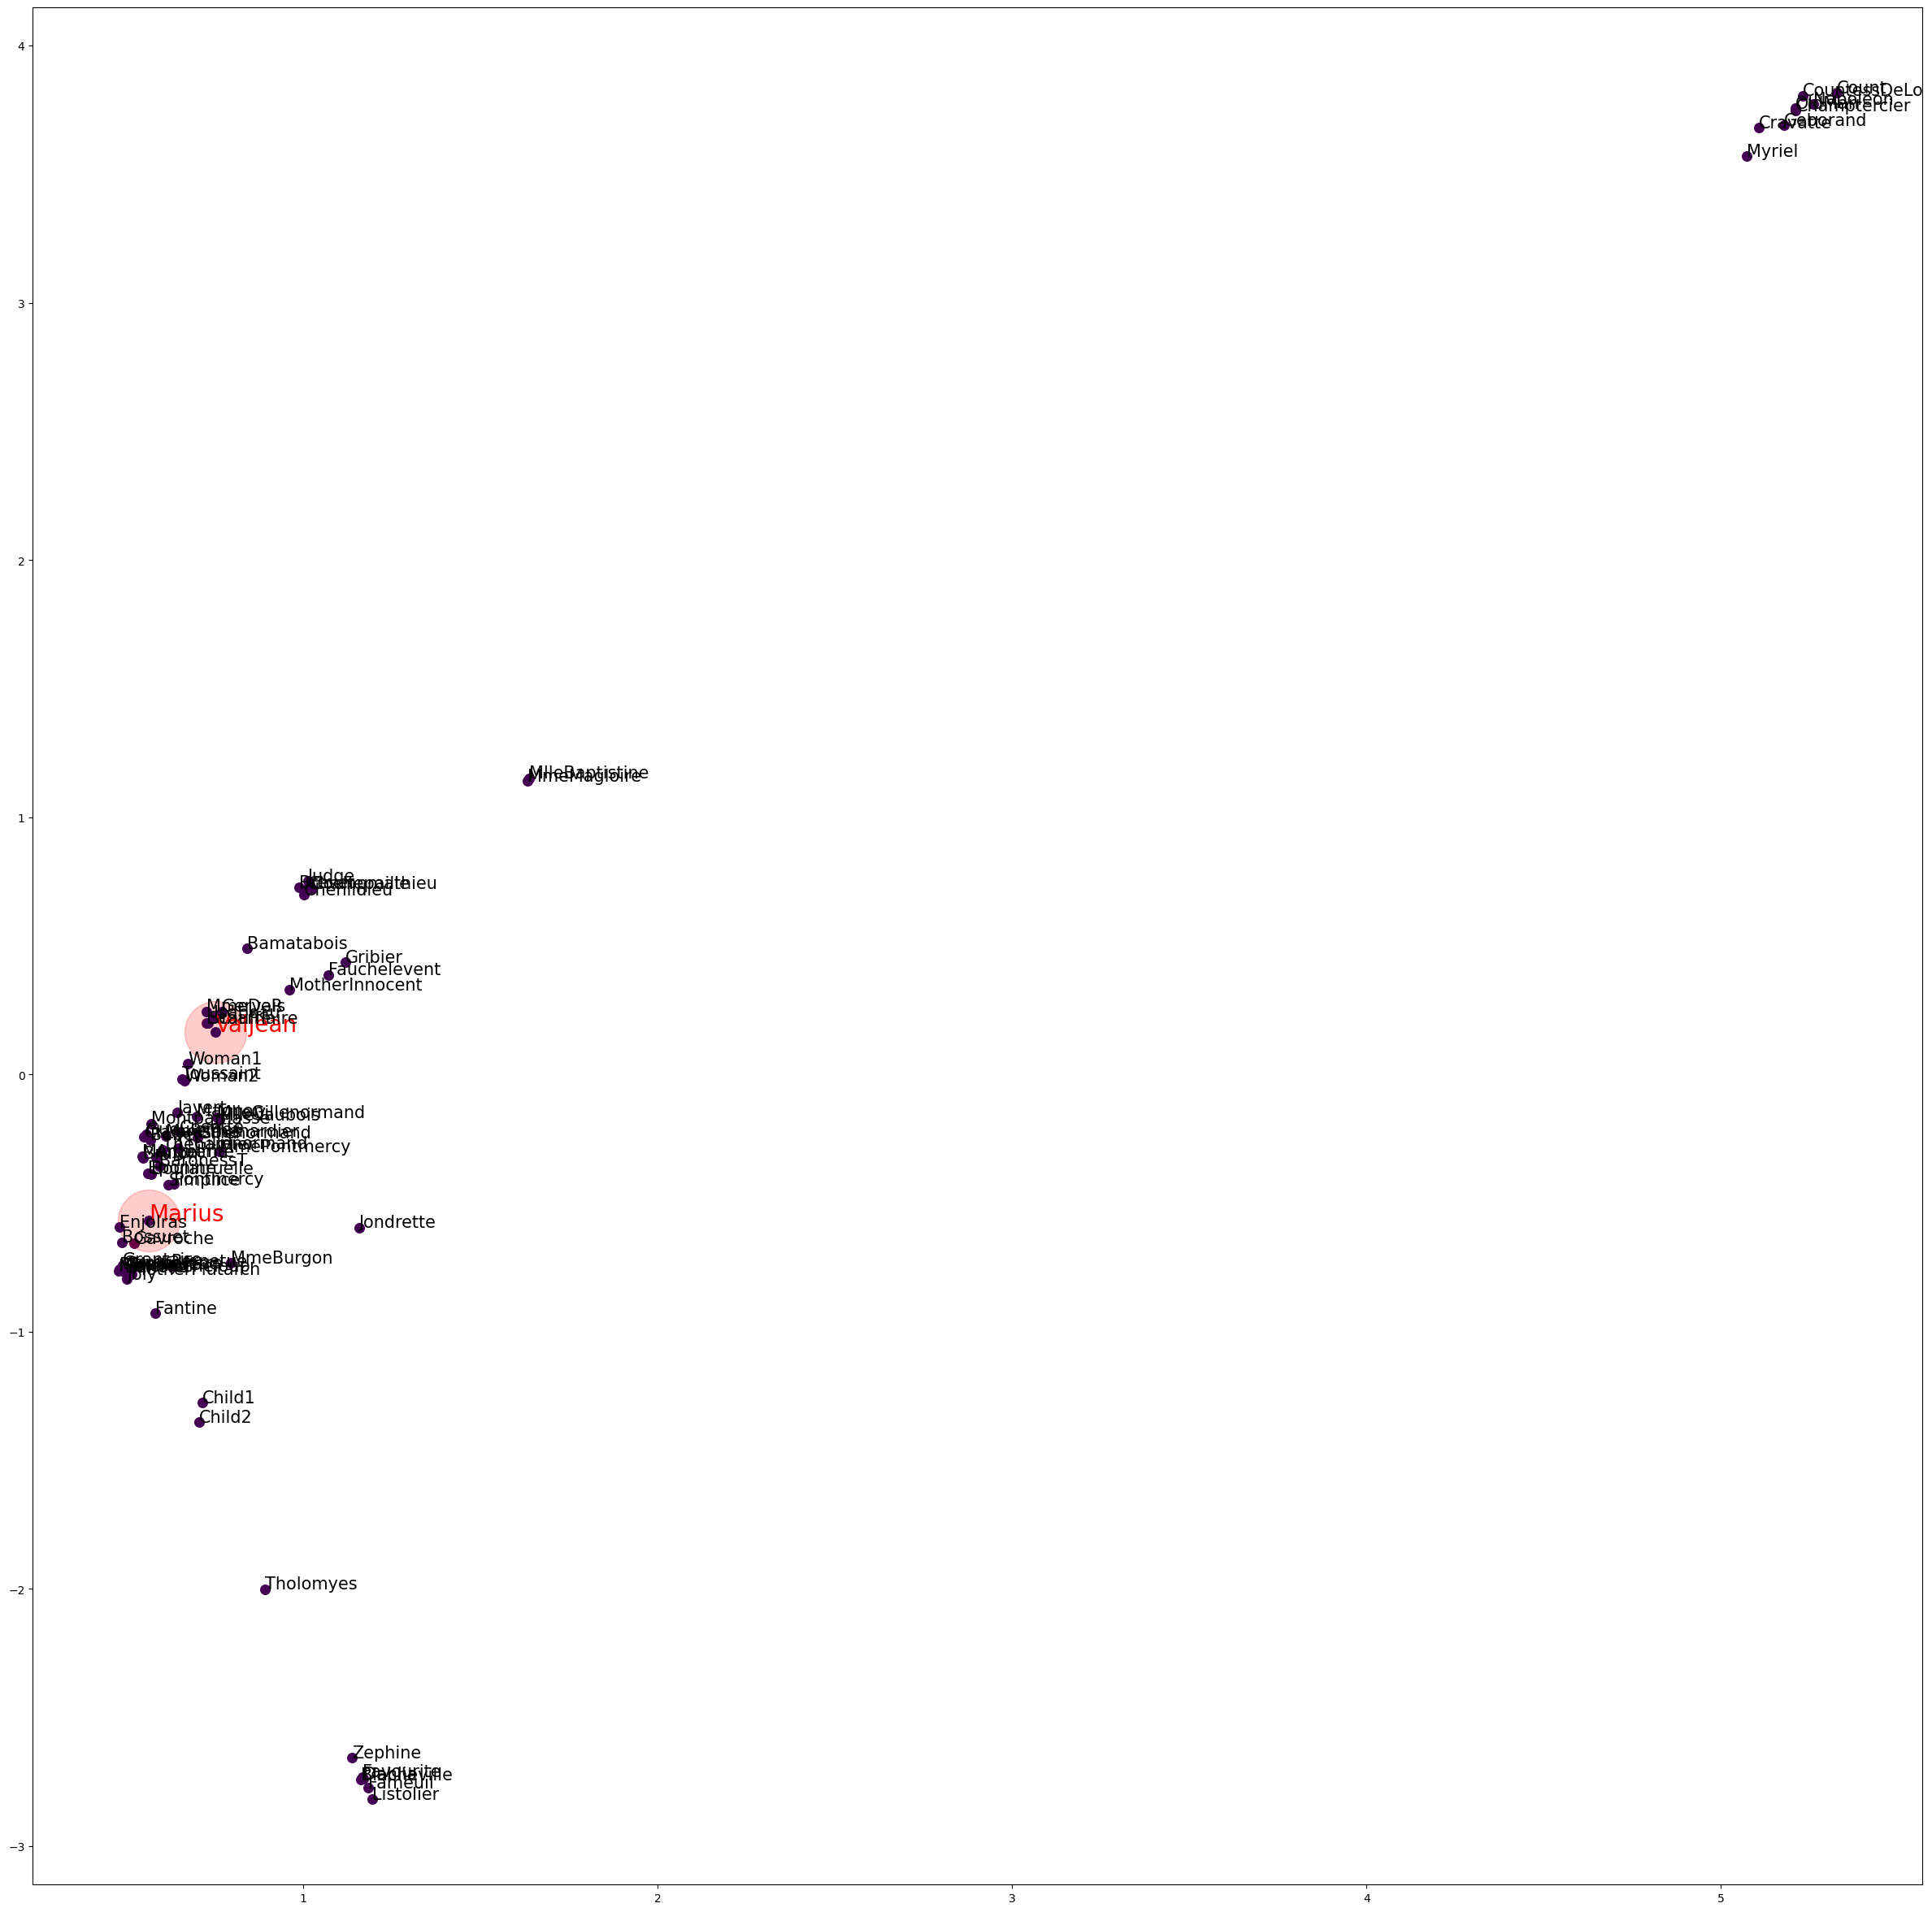

ValjeanのLOF :  1.1109557833514212
MariusのLOF :  1.2313145565791563


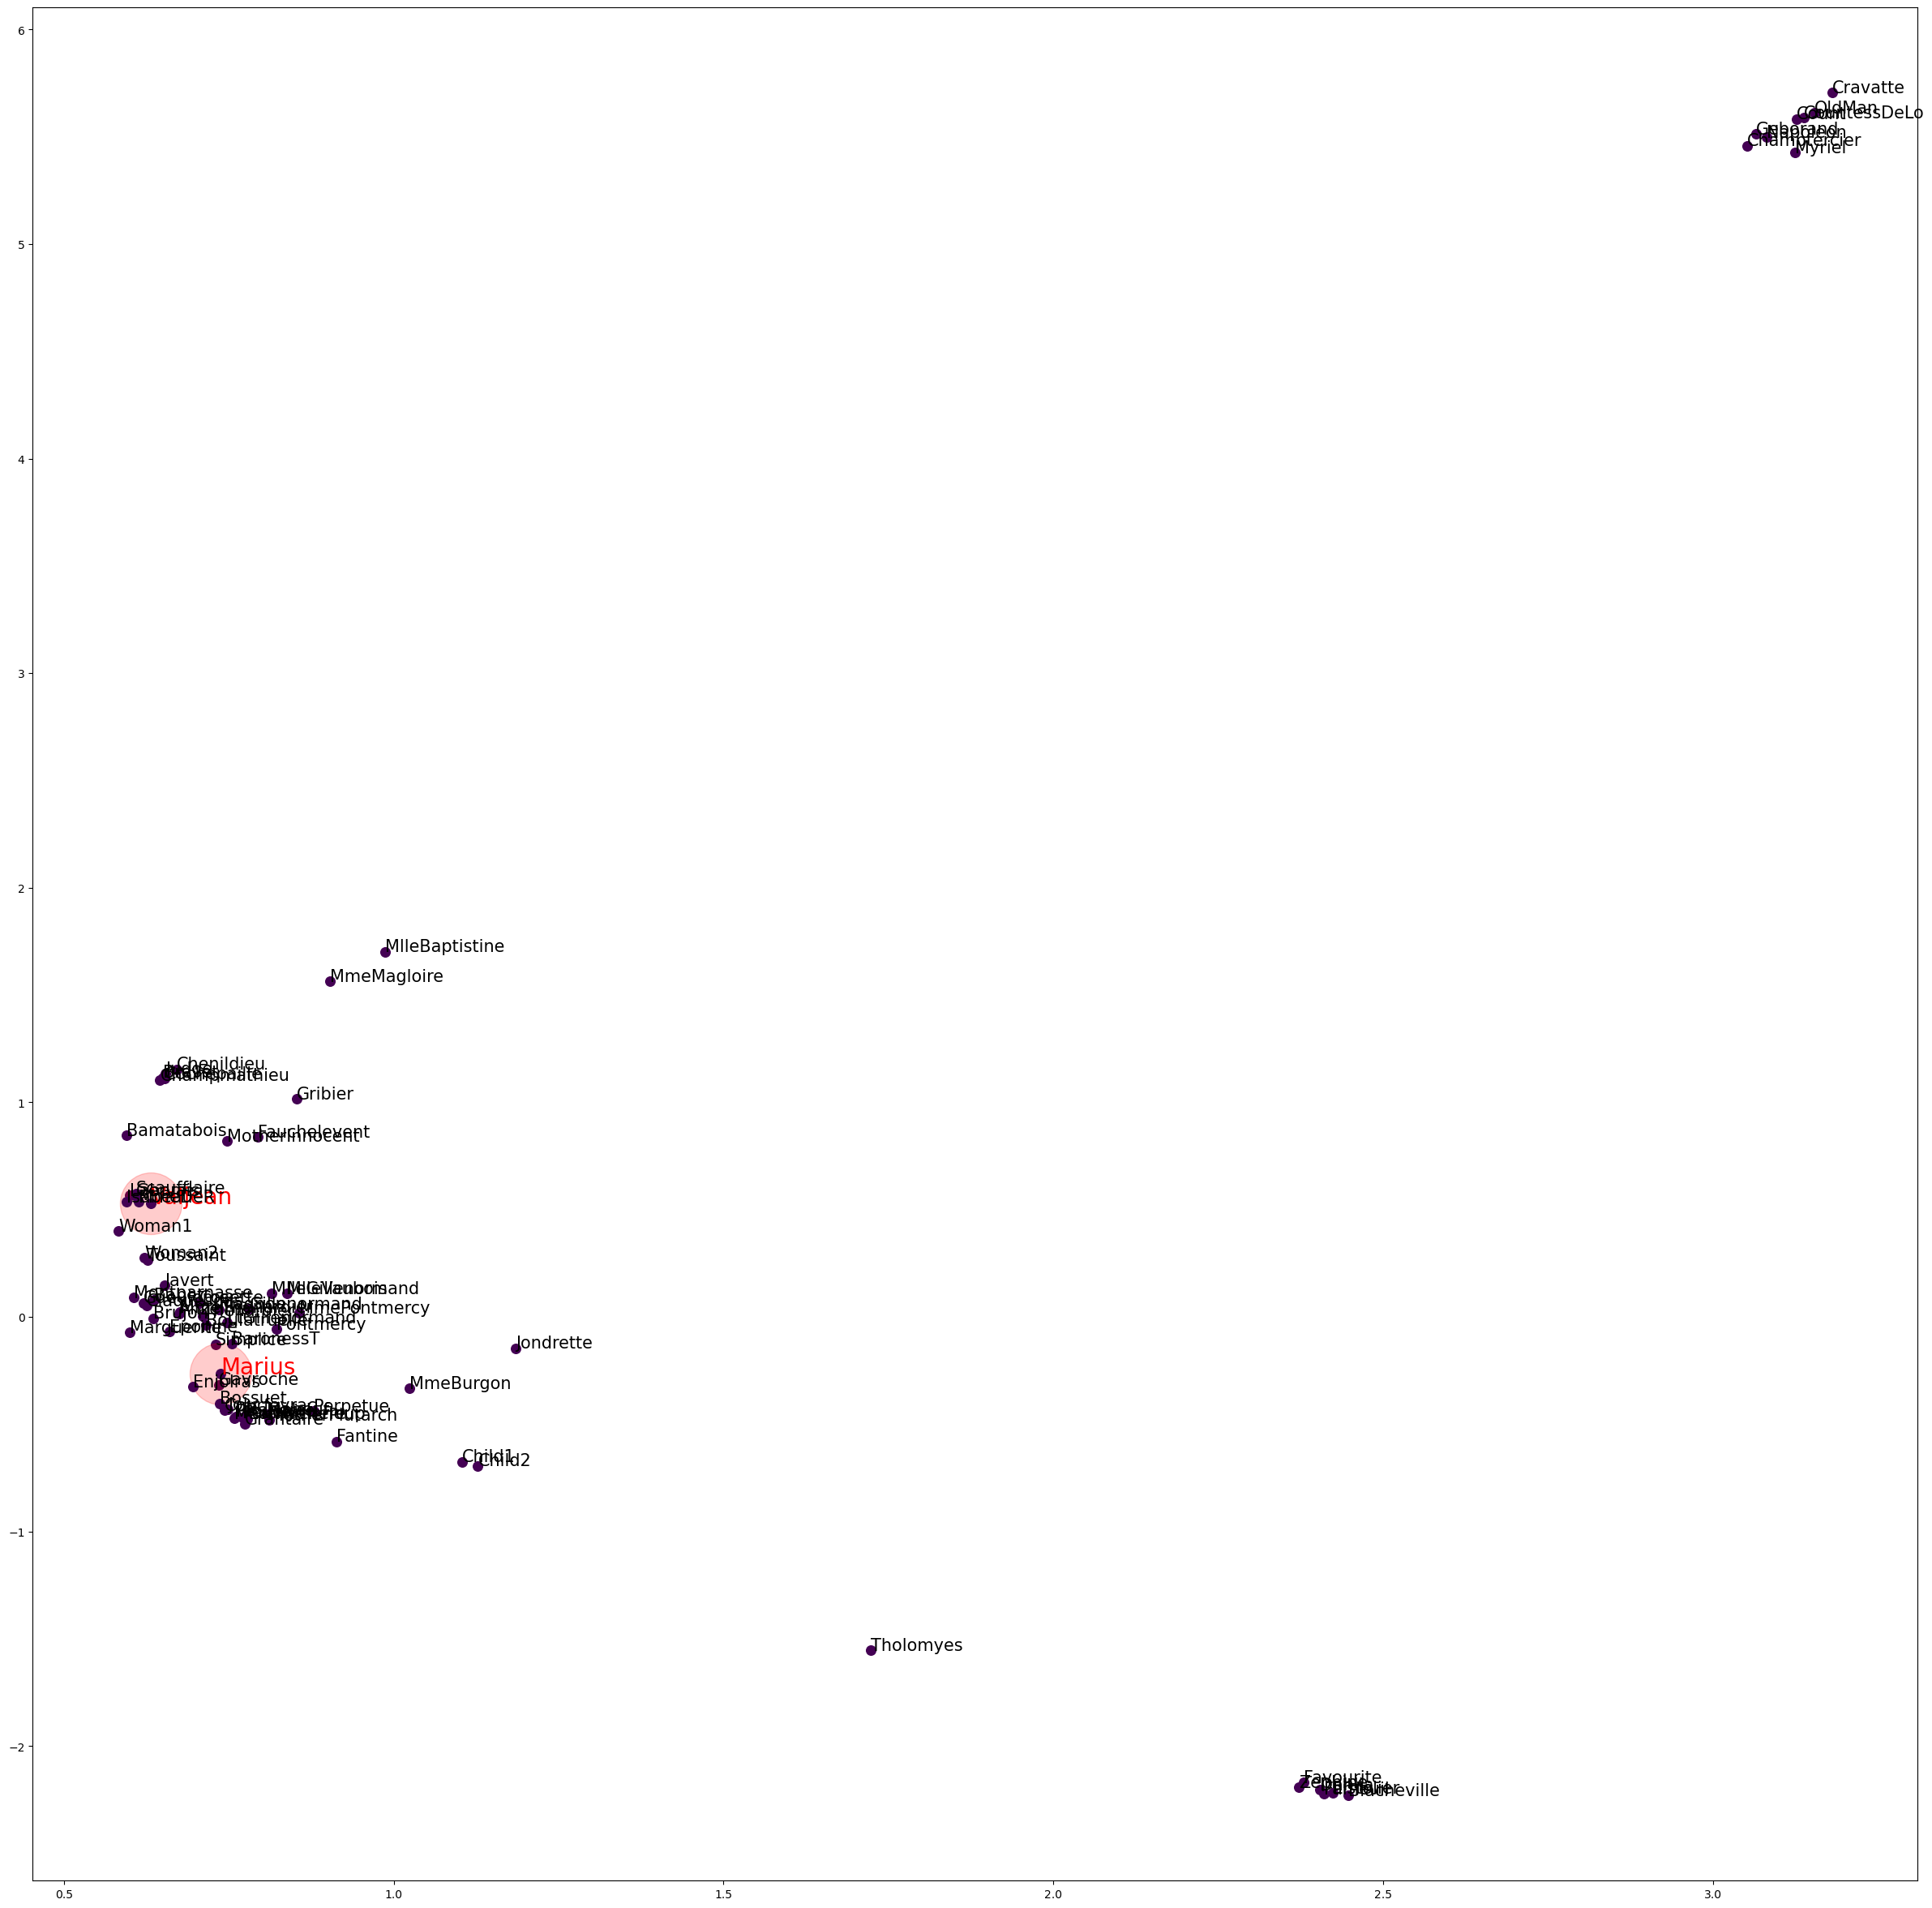

ValjeanのLOF :  1.0878133111180193
MariusのLOF :  1.1834864821177624


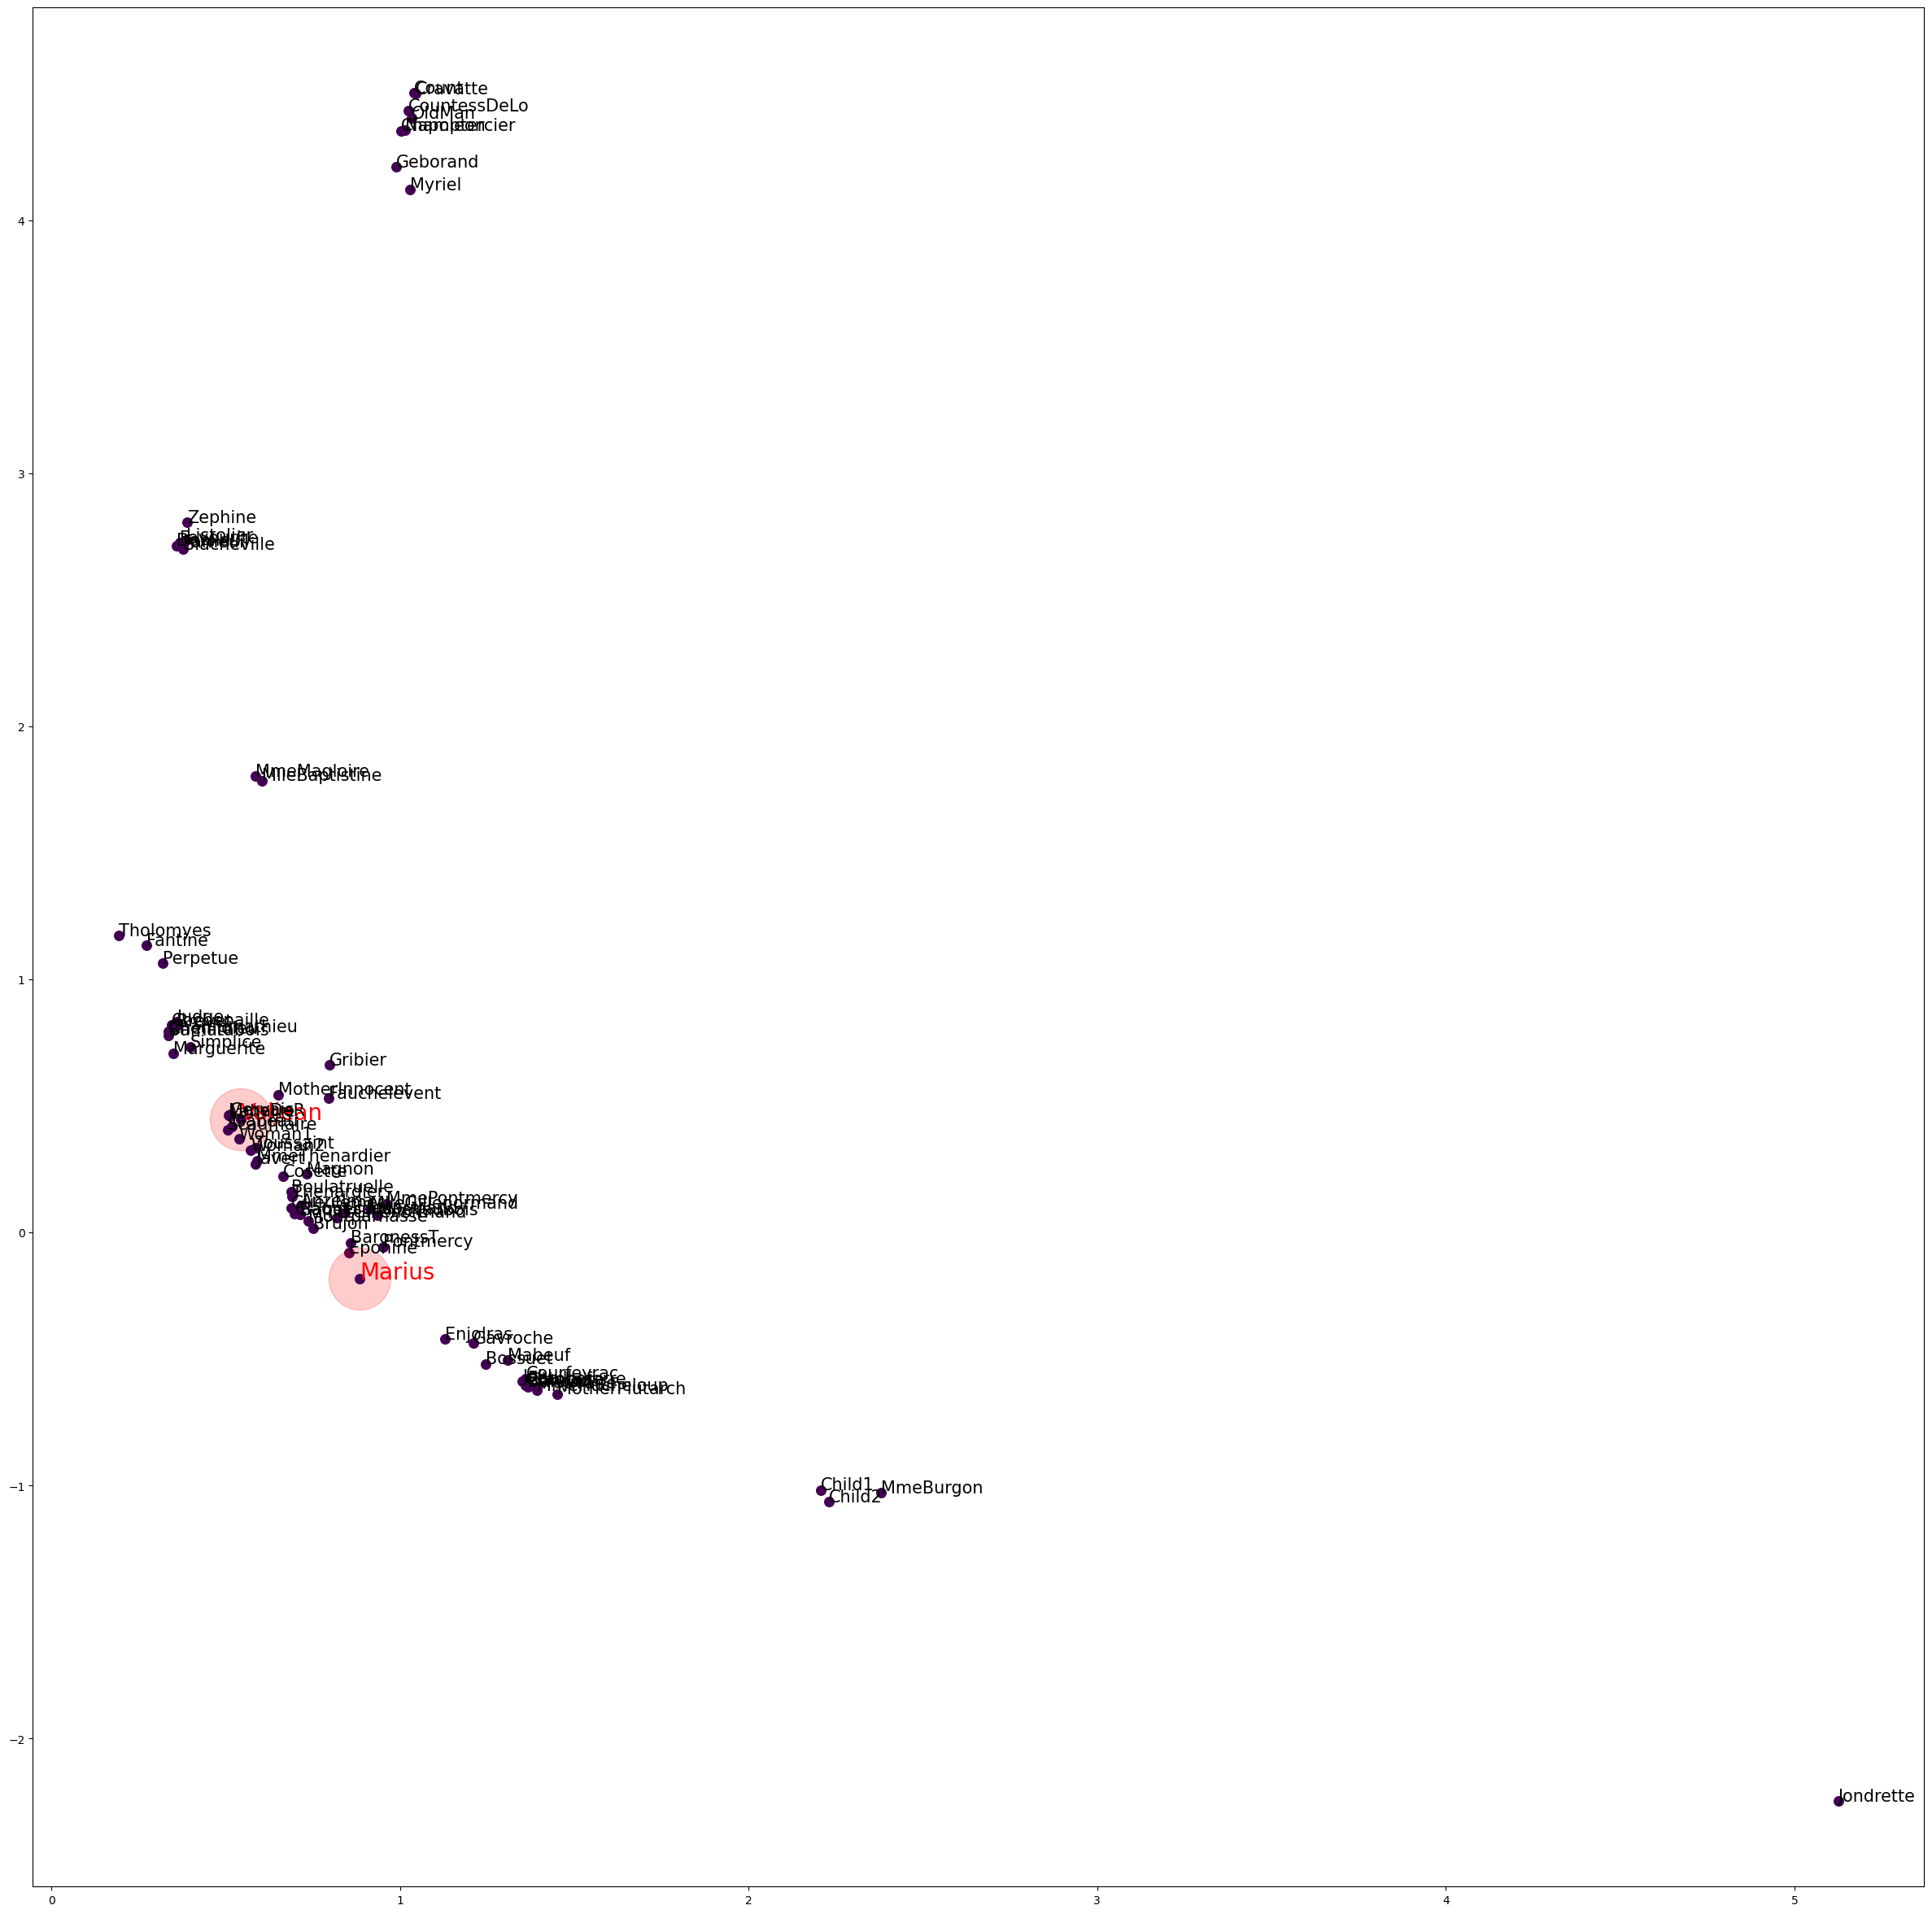

ValjeanのLOF :  1.0144088061333196
MariusのLOF :  1.3943481578652606


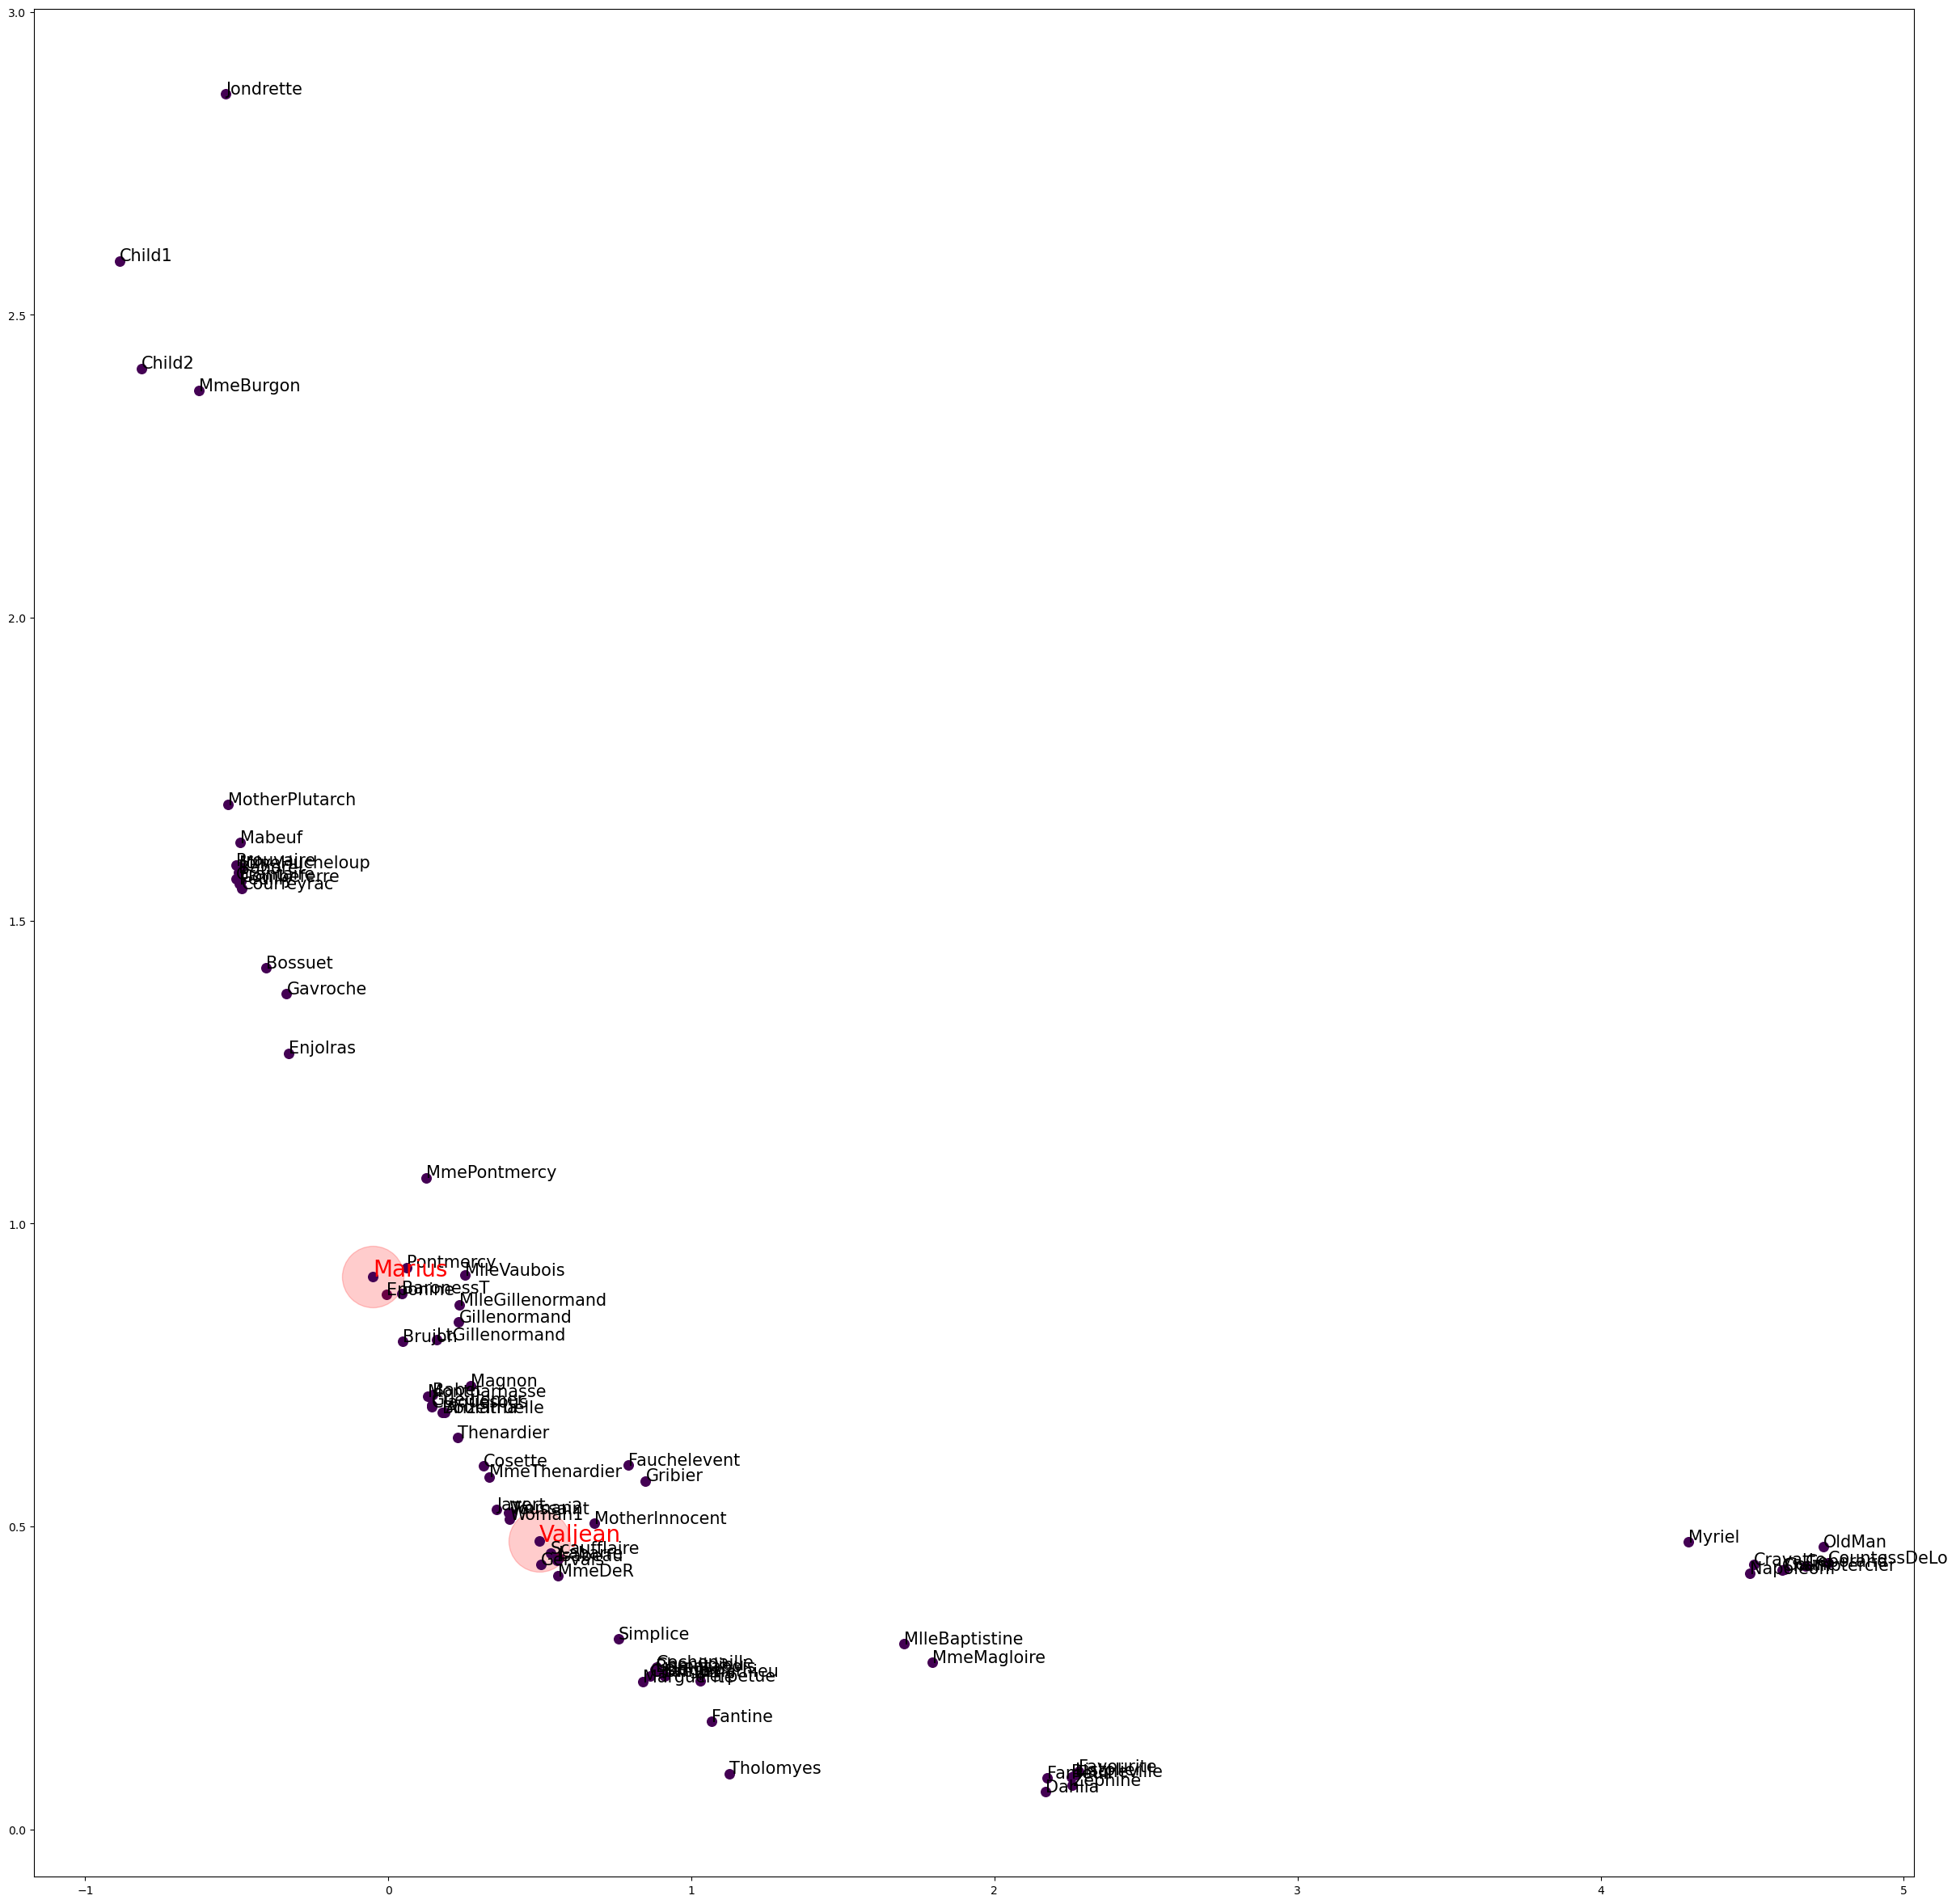

ValjeanのLOF :  1.0722007496140011
MariusのLOF :  0.9927280371873567


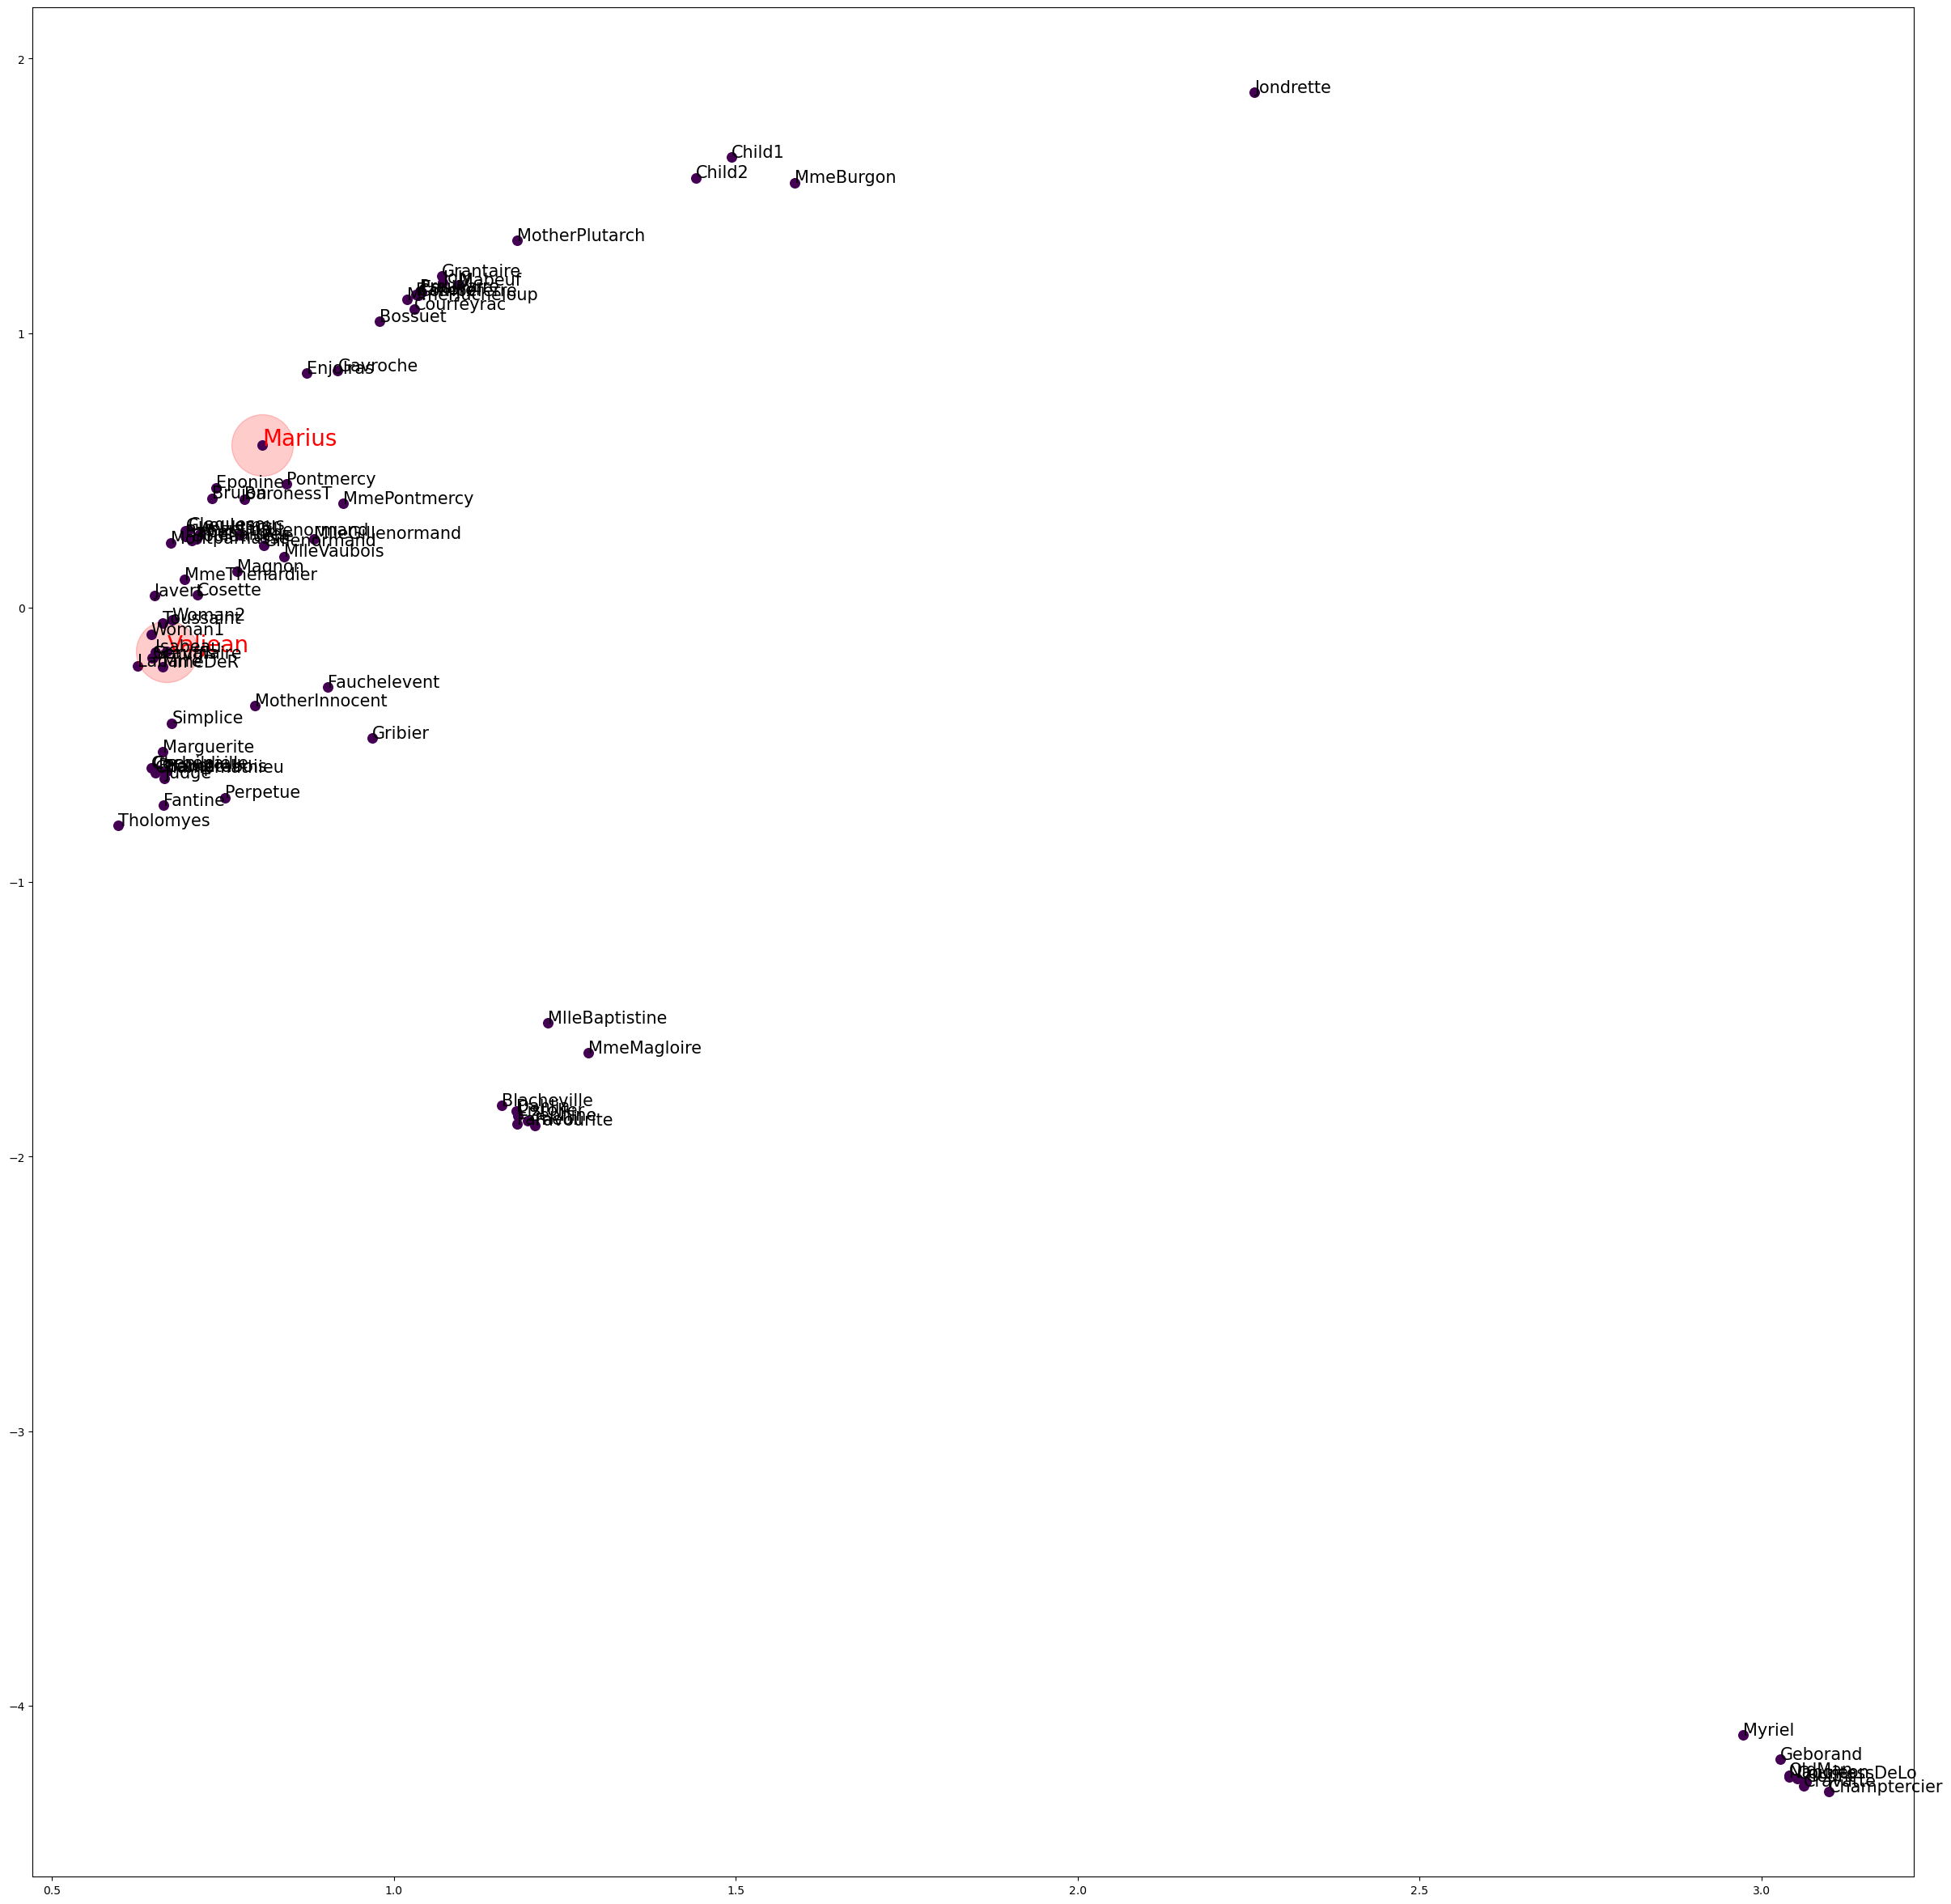

ValjeanのLOF :  0.95061562193096
MariusのLOF :  1.3212590765546195


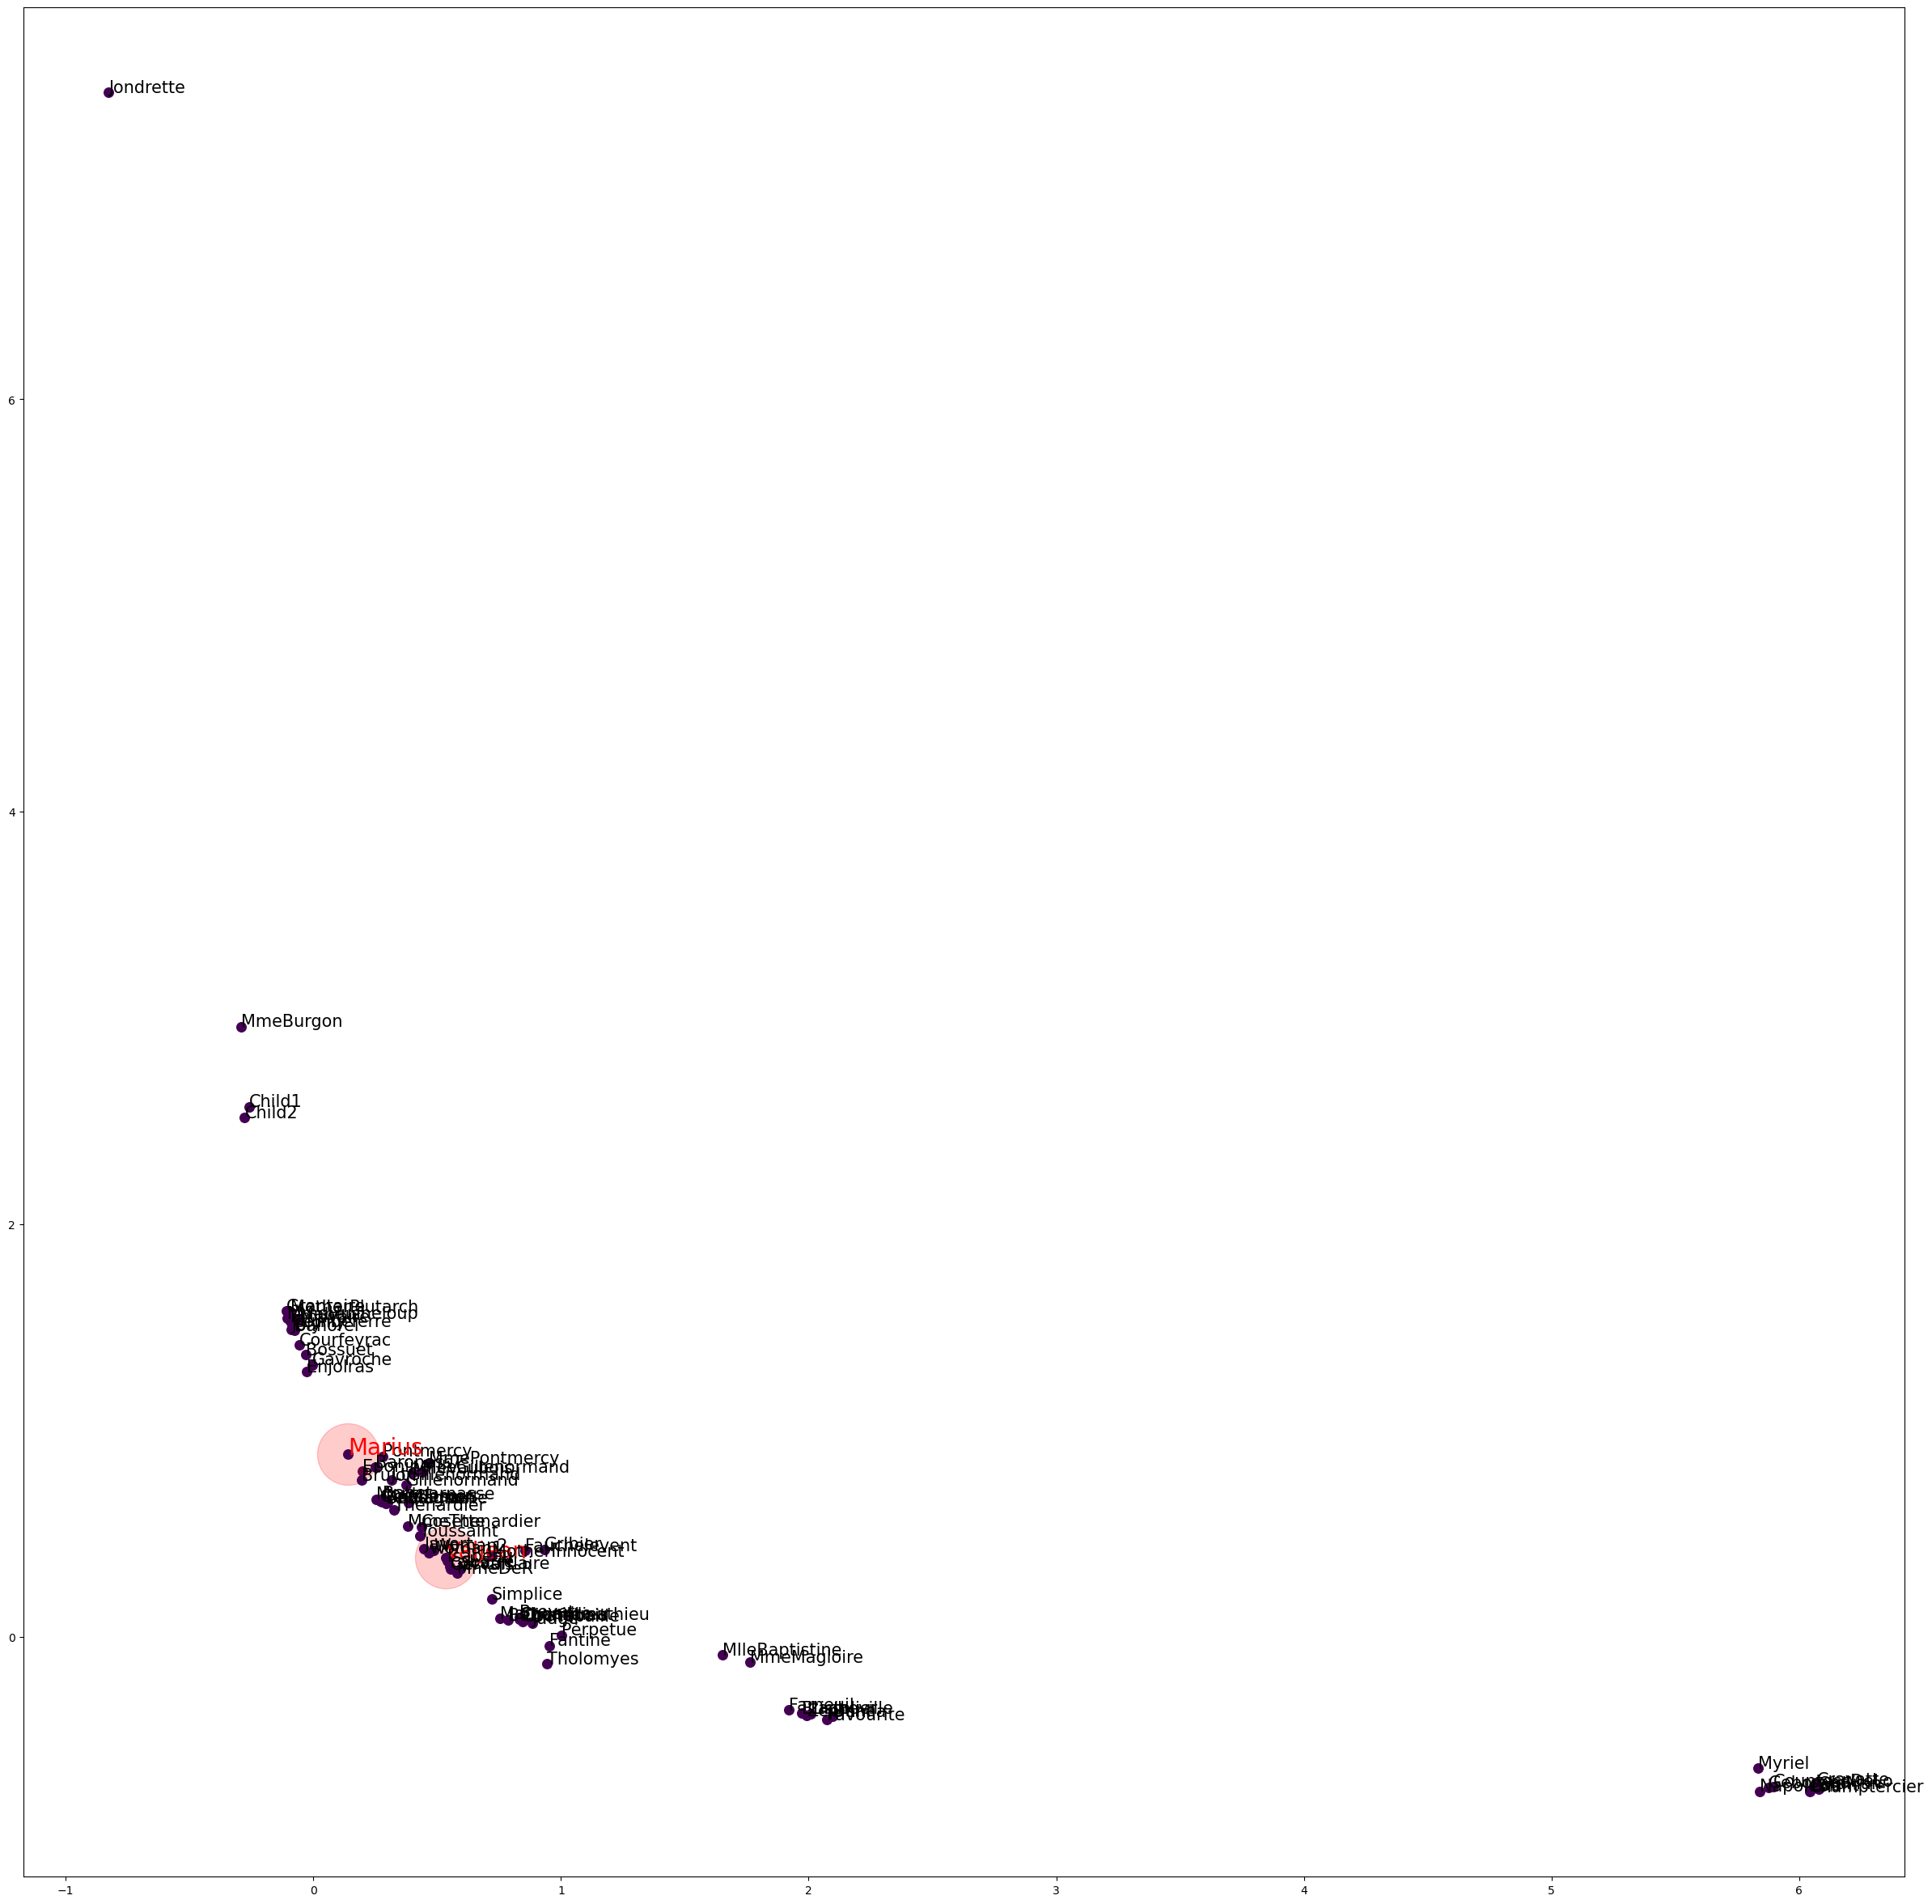

ValjeanのLOF :  0.9994553269162312
MariusのLOF :  1.119874715177251


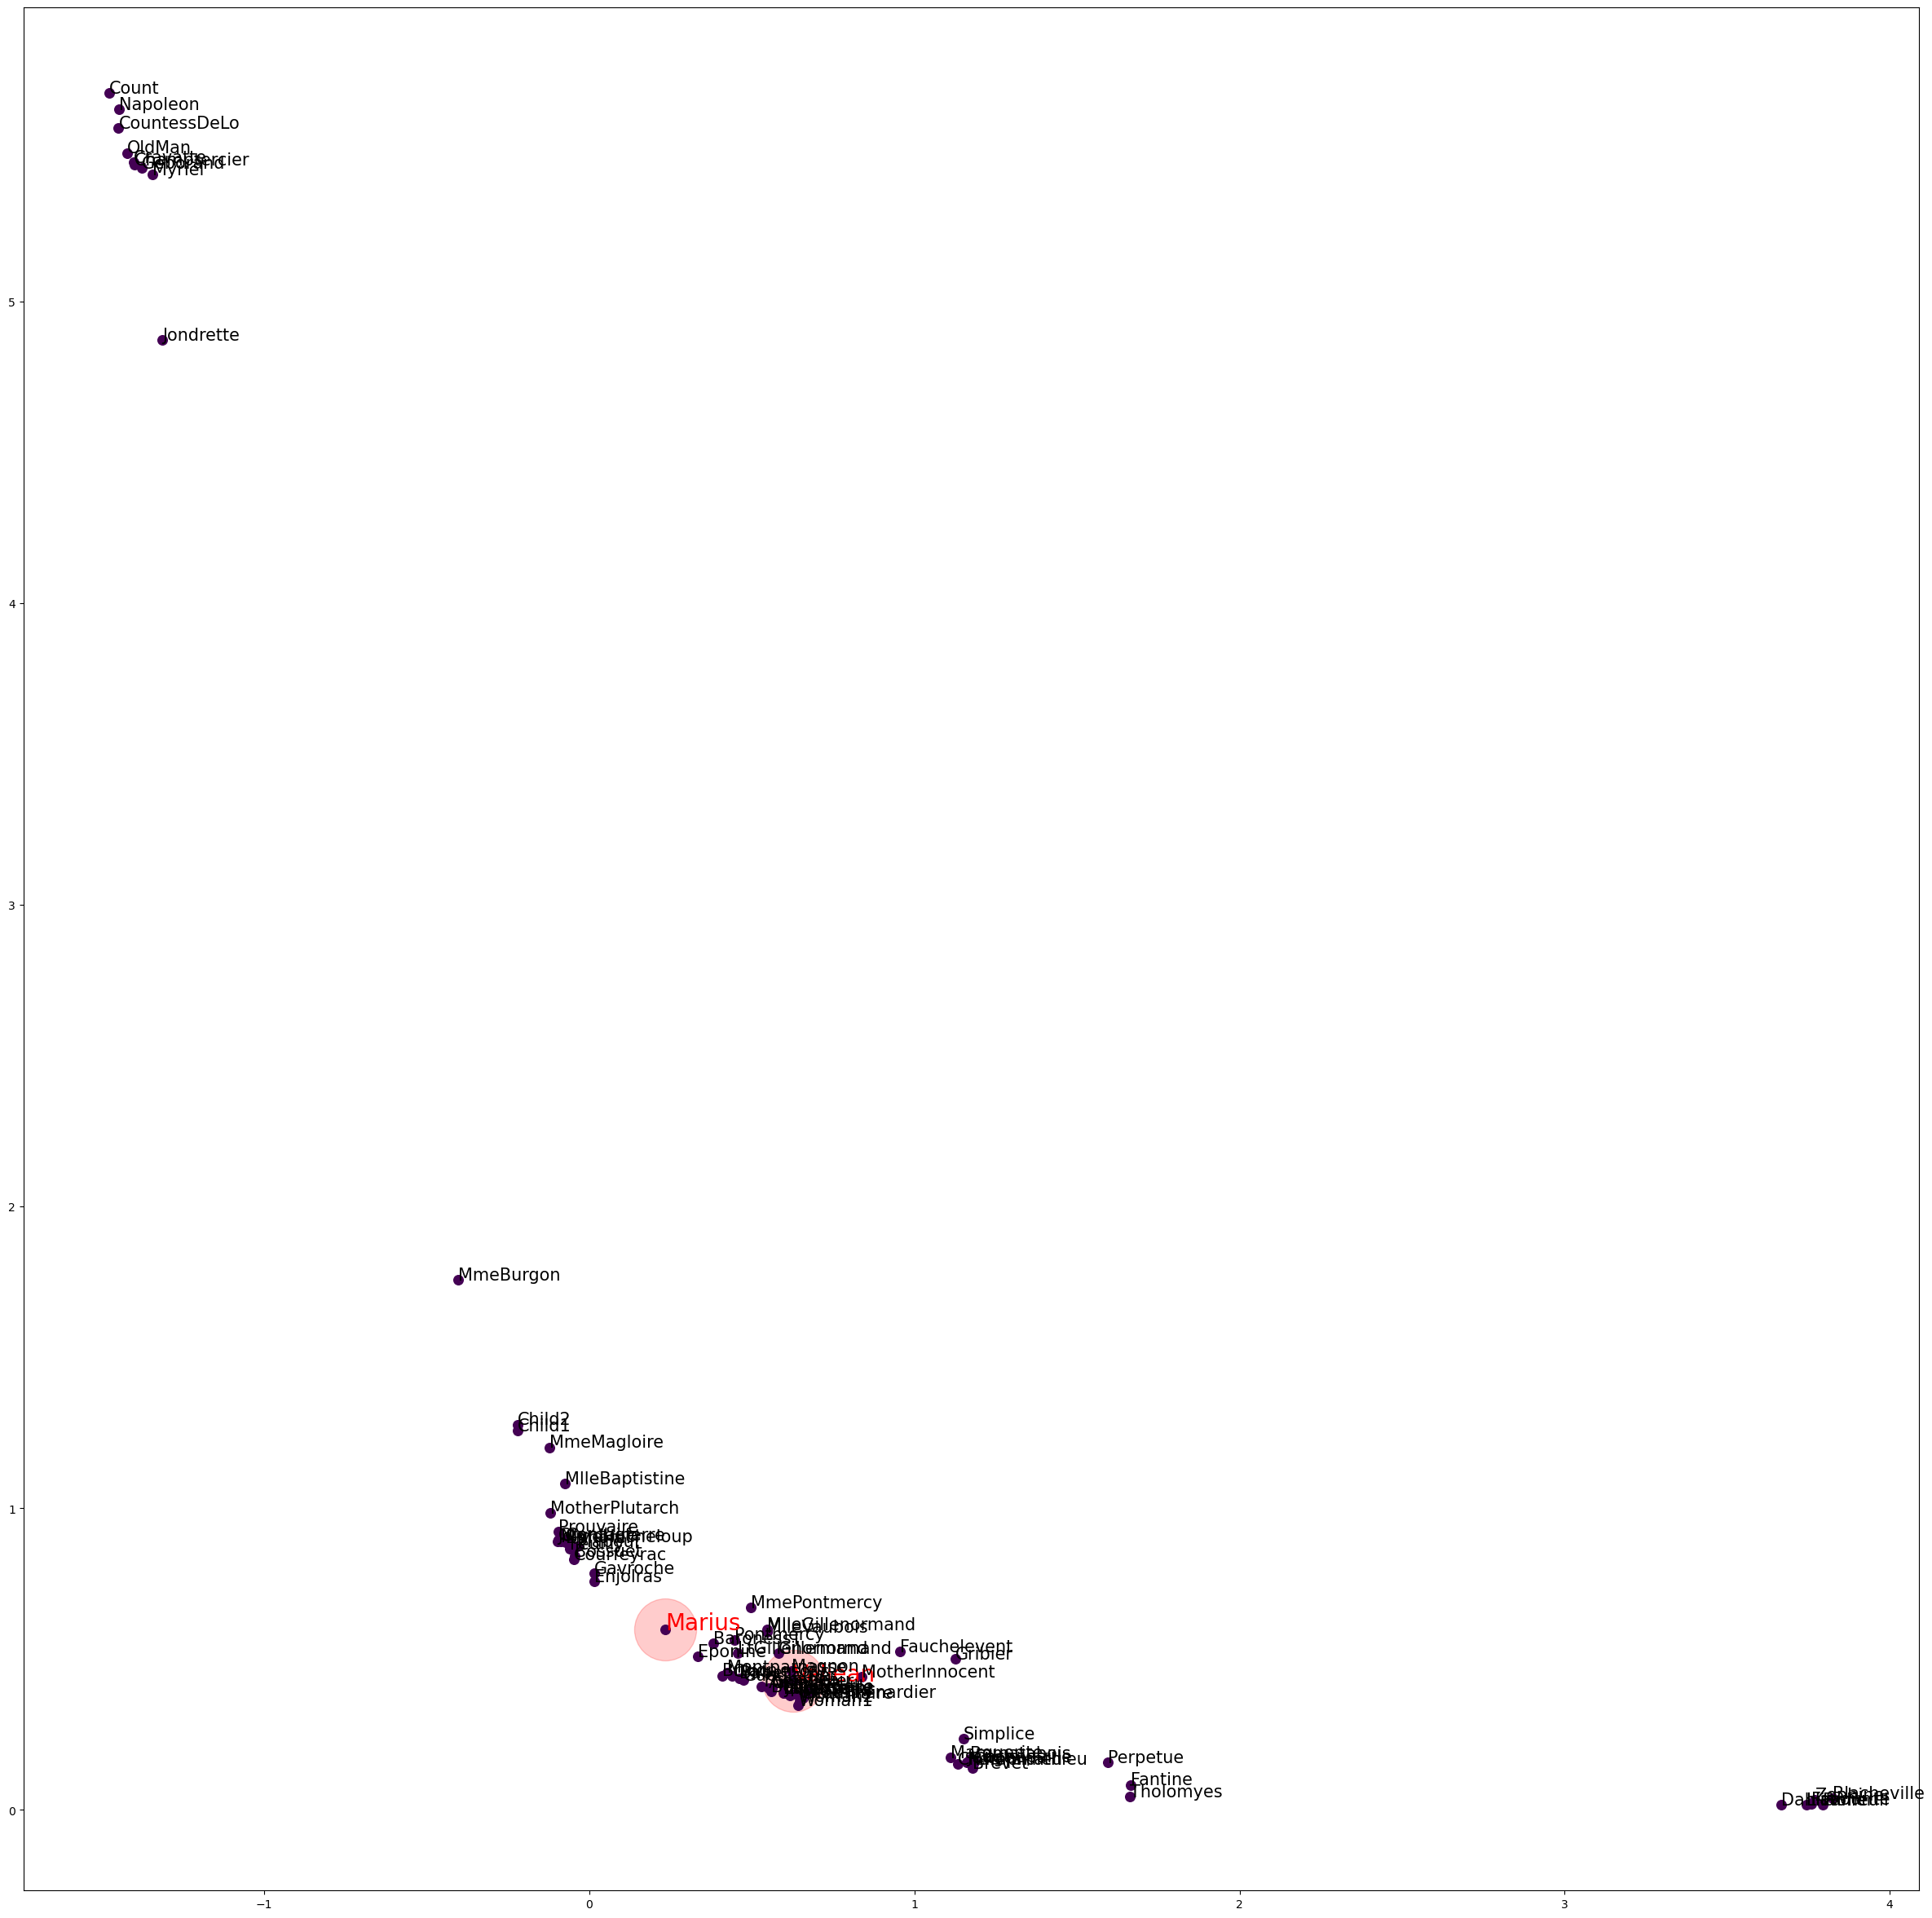

ValjeanのLOF :  1.3243294699970254
MariusのLOF :  2.1830820163731723


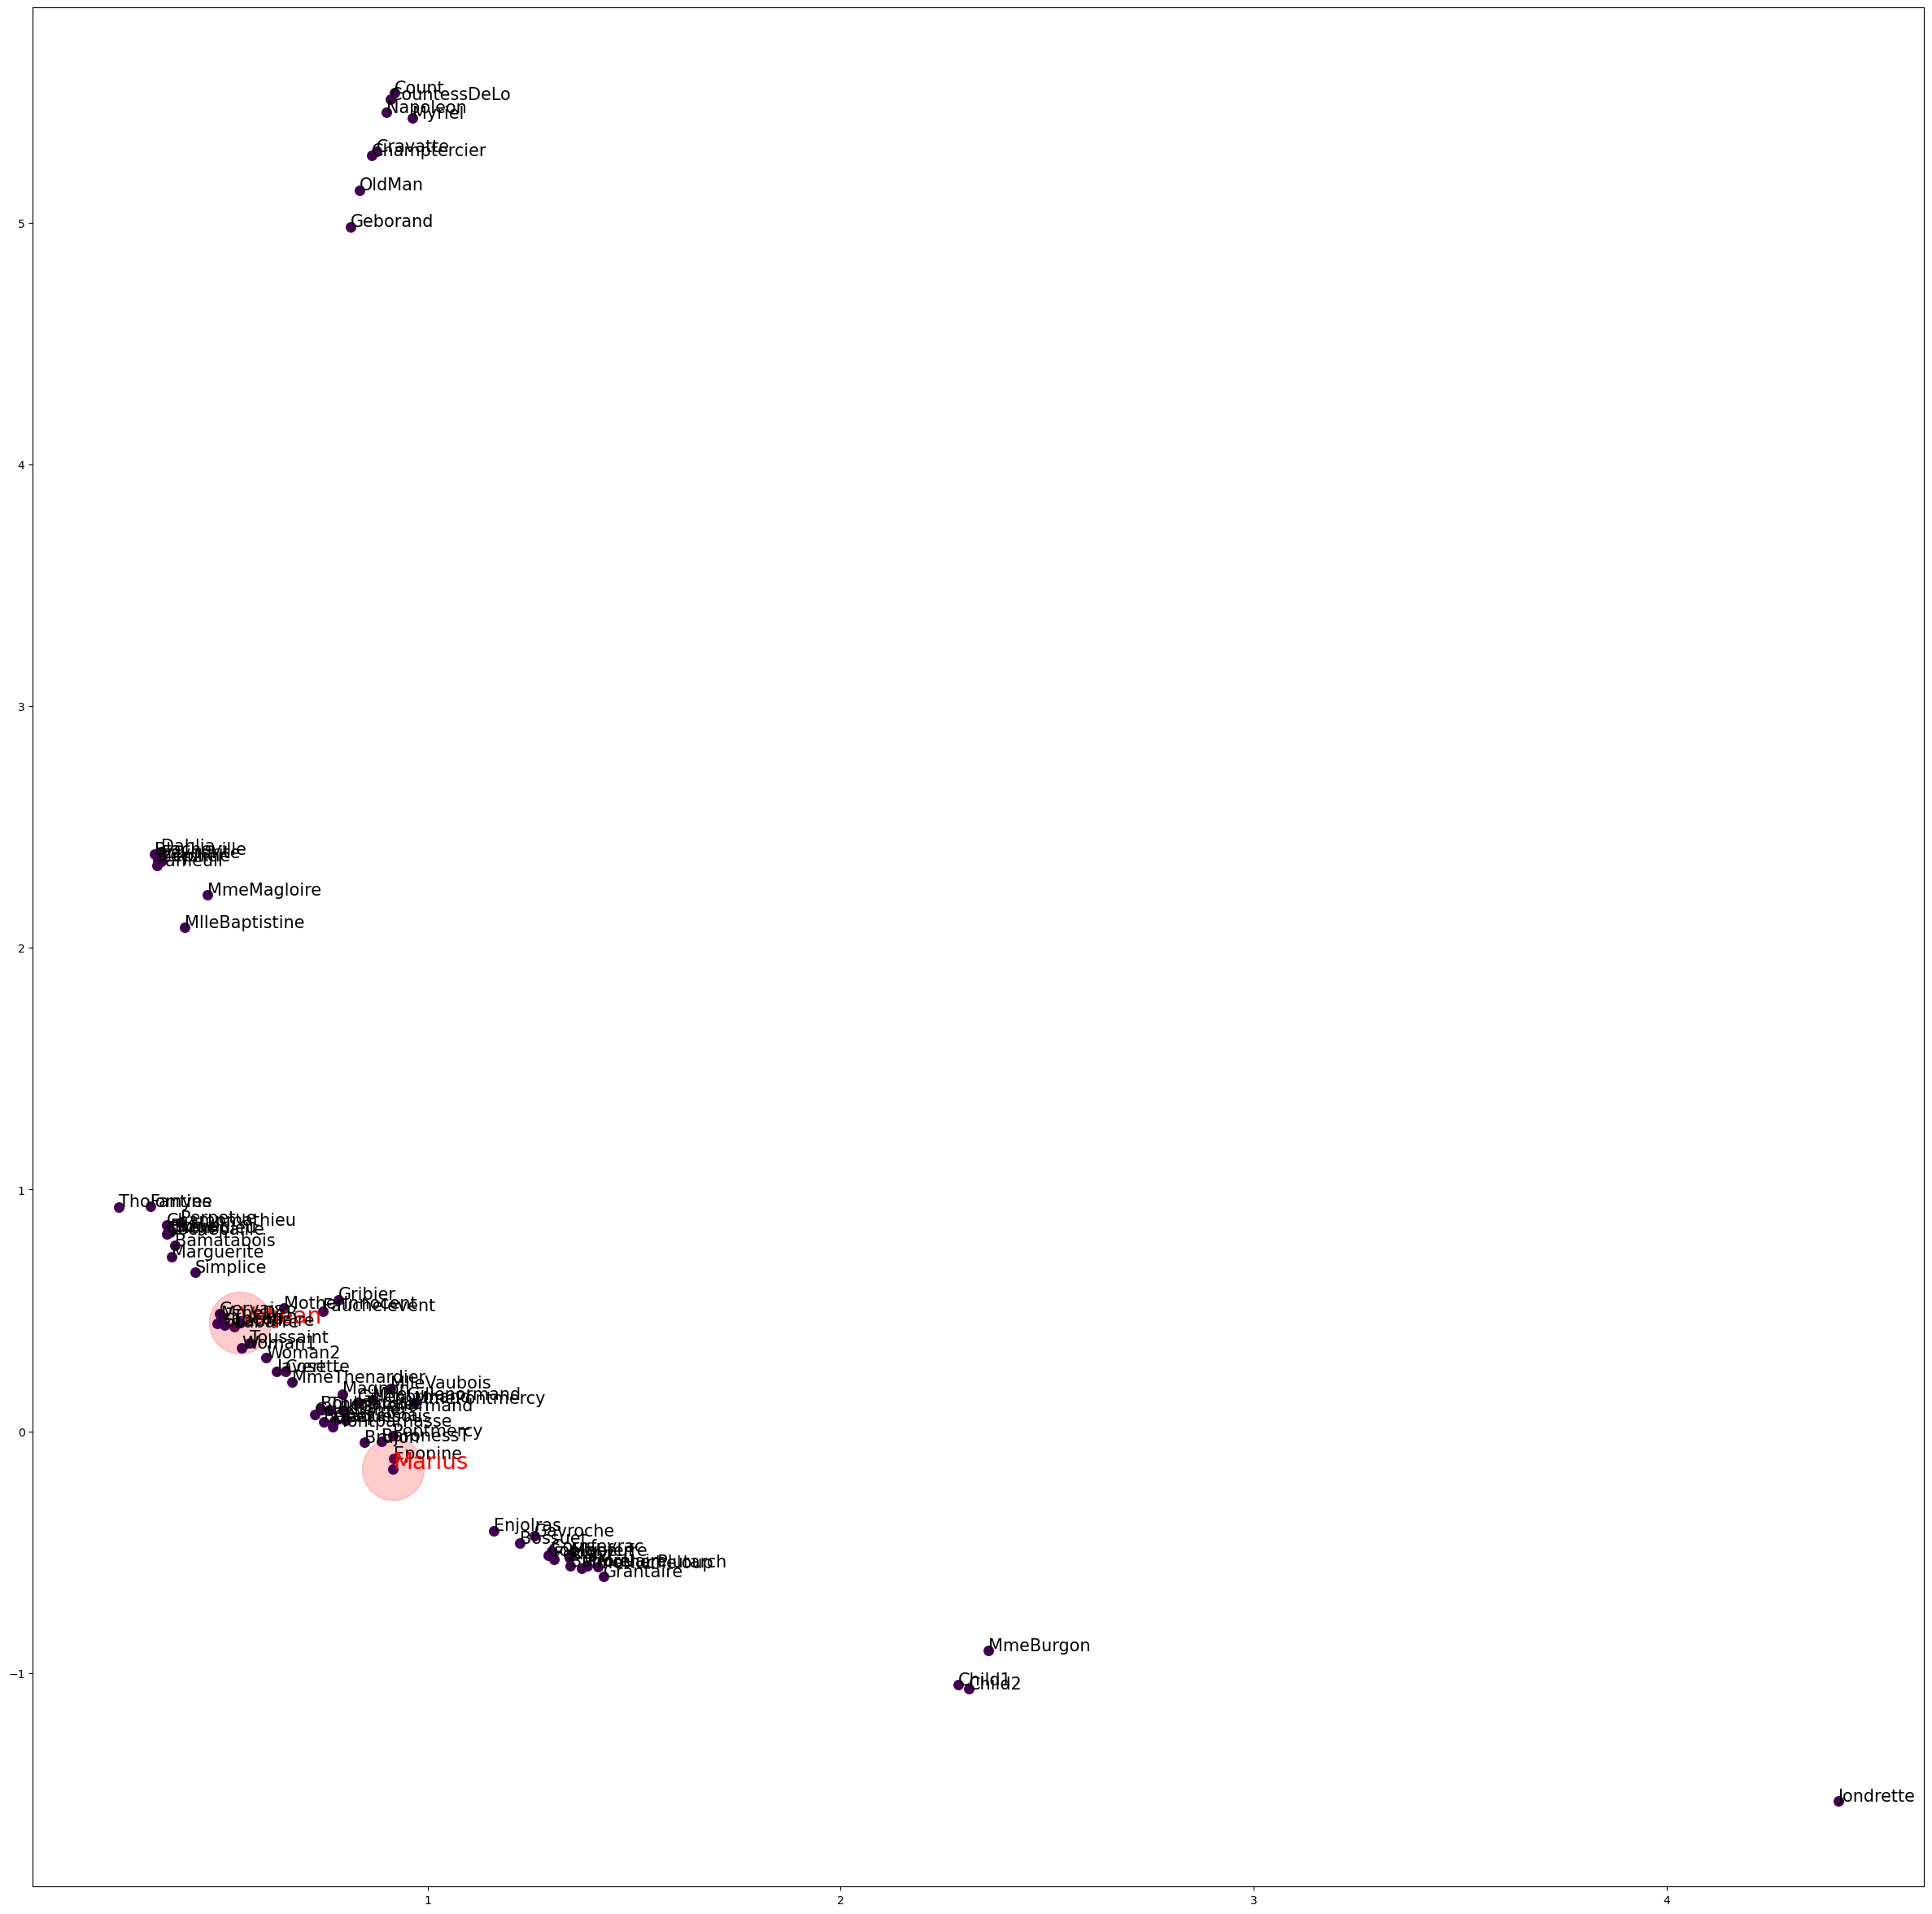

ValjeanのLOF :  0.988352933455332
MariusのLOF :  1.0473734522255678


In [6]:

for i in range(100):
    # インプットするグラフ生成とラベルの取得(ラベルなしデータはNone)
    INPUT, TRUE_LABEL = dwlesmis.generate_Graph("lesmis")

    #埋め込み
    vec,walks = dwlesmis.embed(INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS)

    lof = dwlesmis.culc_lof(vec, k = 4)
    #node_annotationとlofの値を辞書型で結合

    #アノテーション作成
    node_annotation = [i for i in INPUT.nodes()]
    
    node_lof = dict(zip(node_annotation,lof))

    if (node_lof["Valjean"]<30 and node_lof["Marius"]<30):

        #ValjeanとMariusのLOFを取得
        Valjean_lof.append(node_lof["Valjean"])
        Marius_lof.append(node_lof["Marius"])

        #正規化
        mm = preprocessing.MinMaxScaler()
        vec_pre = mm.fit_transform(vec)
        
        #可視化
        dwlesmis.draw_embedded_vector(vec_pre,node_annotation=node_annotation,ATTENTION_NODE_LIST=ATTENTION_NODE_LIST)

        print("ValjeanのLOF : ",node_lof["Valjean"])
        print("MariusのLOF : ",node_lof["Marius"])


print("")
#lofの最大最小平均標準偏差を計算
print("Valjean_lof")
print("max:",max(Valjean_lof))
print("min:",min(Valjean_lof))
print("mean:",np.mean(Valjean_lof))
print("std:",np.std(Valjean_lof))

print("Marius_lof")
print("max:",max(Marius_lof))
print("min:",min(Marius_lof))
print("mean:",np.mean(Marius_lof))
print("std:",np.std(Marius_lof))
    
    
    
    

In [ ]:
vec,walks = dwlesmis.embed(INPUT, UNDIRECTED, NUMBER_WALKS, WALK_LENGTH, REPRESENTATION_SIZE, WINDOW_SIZE, WORKERS)


In [ ]:
node_annotation = [i for i in INPUT.nodes()]

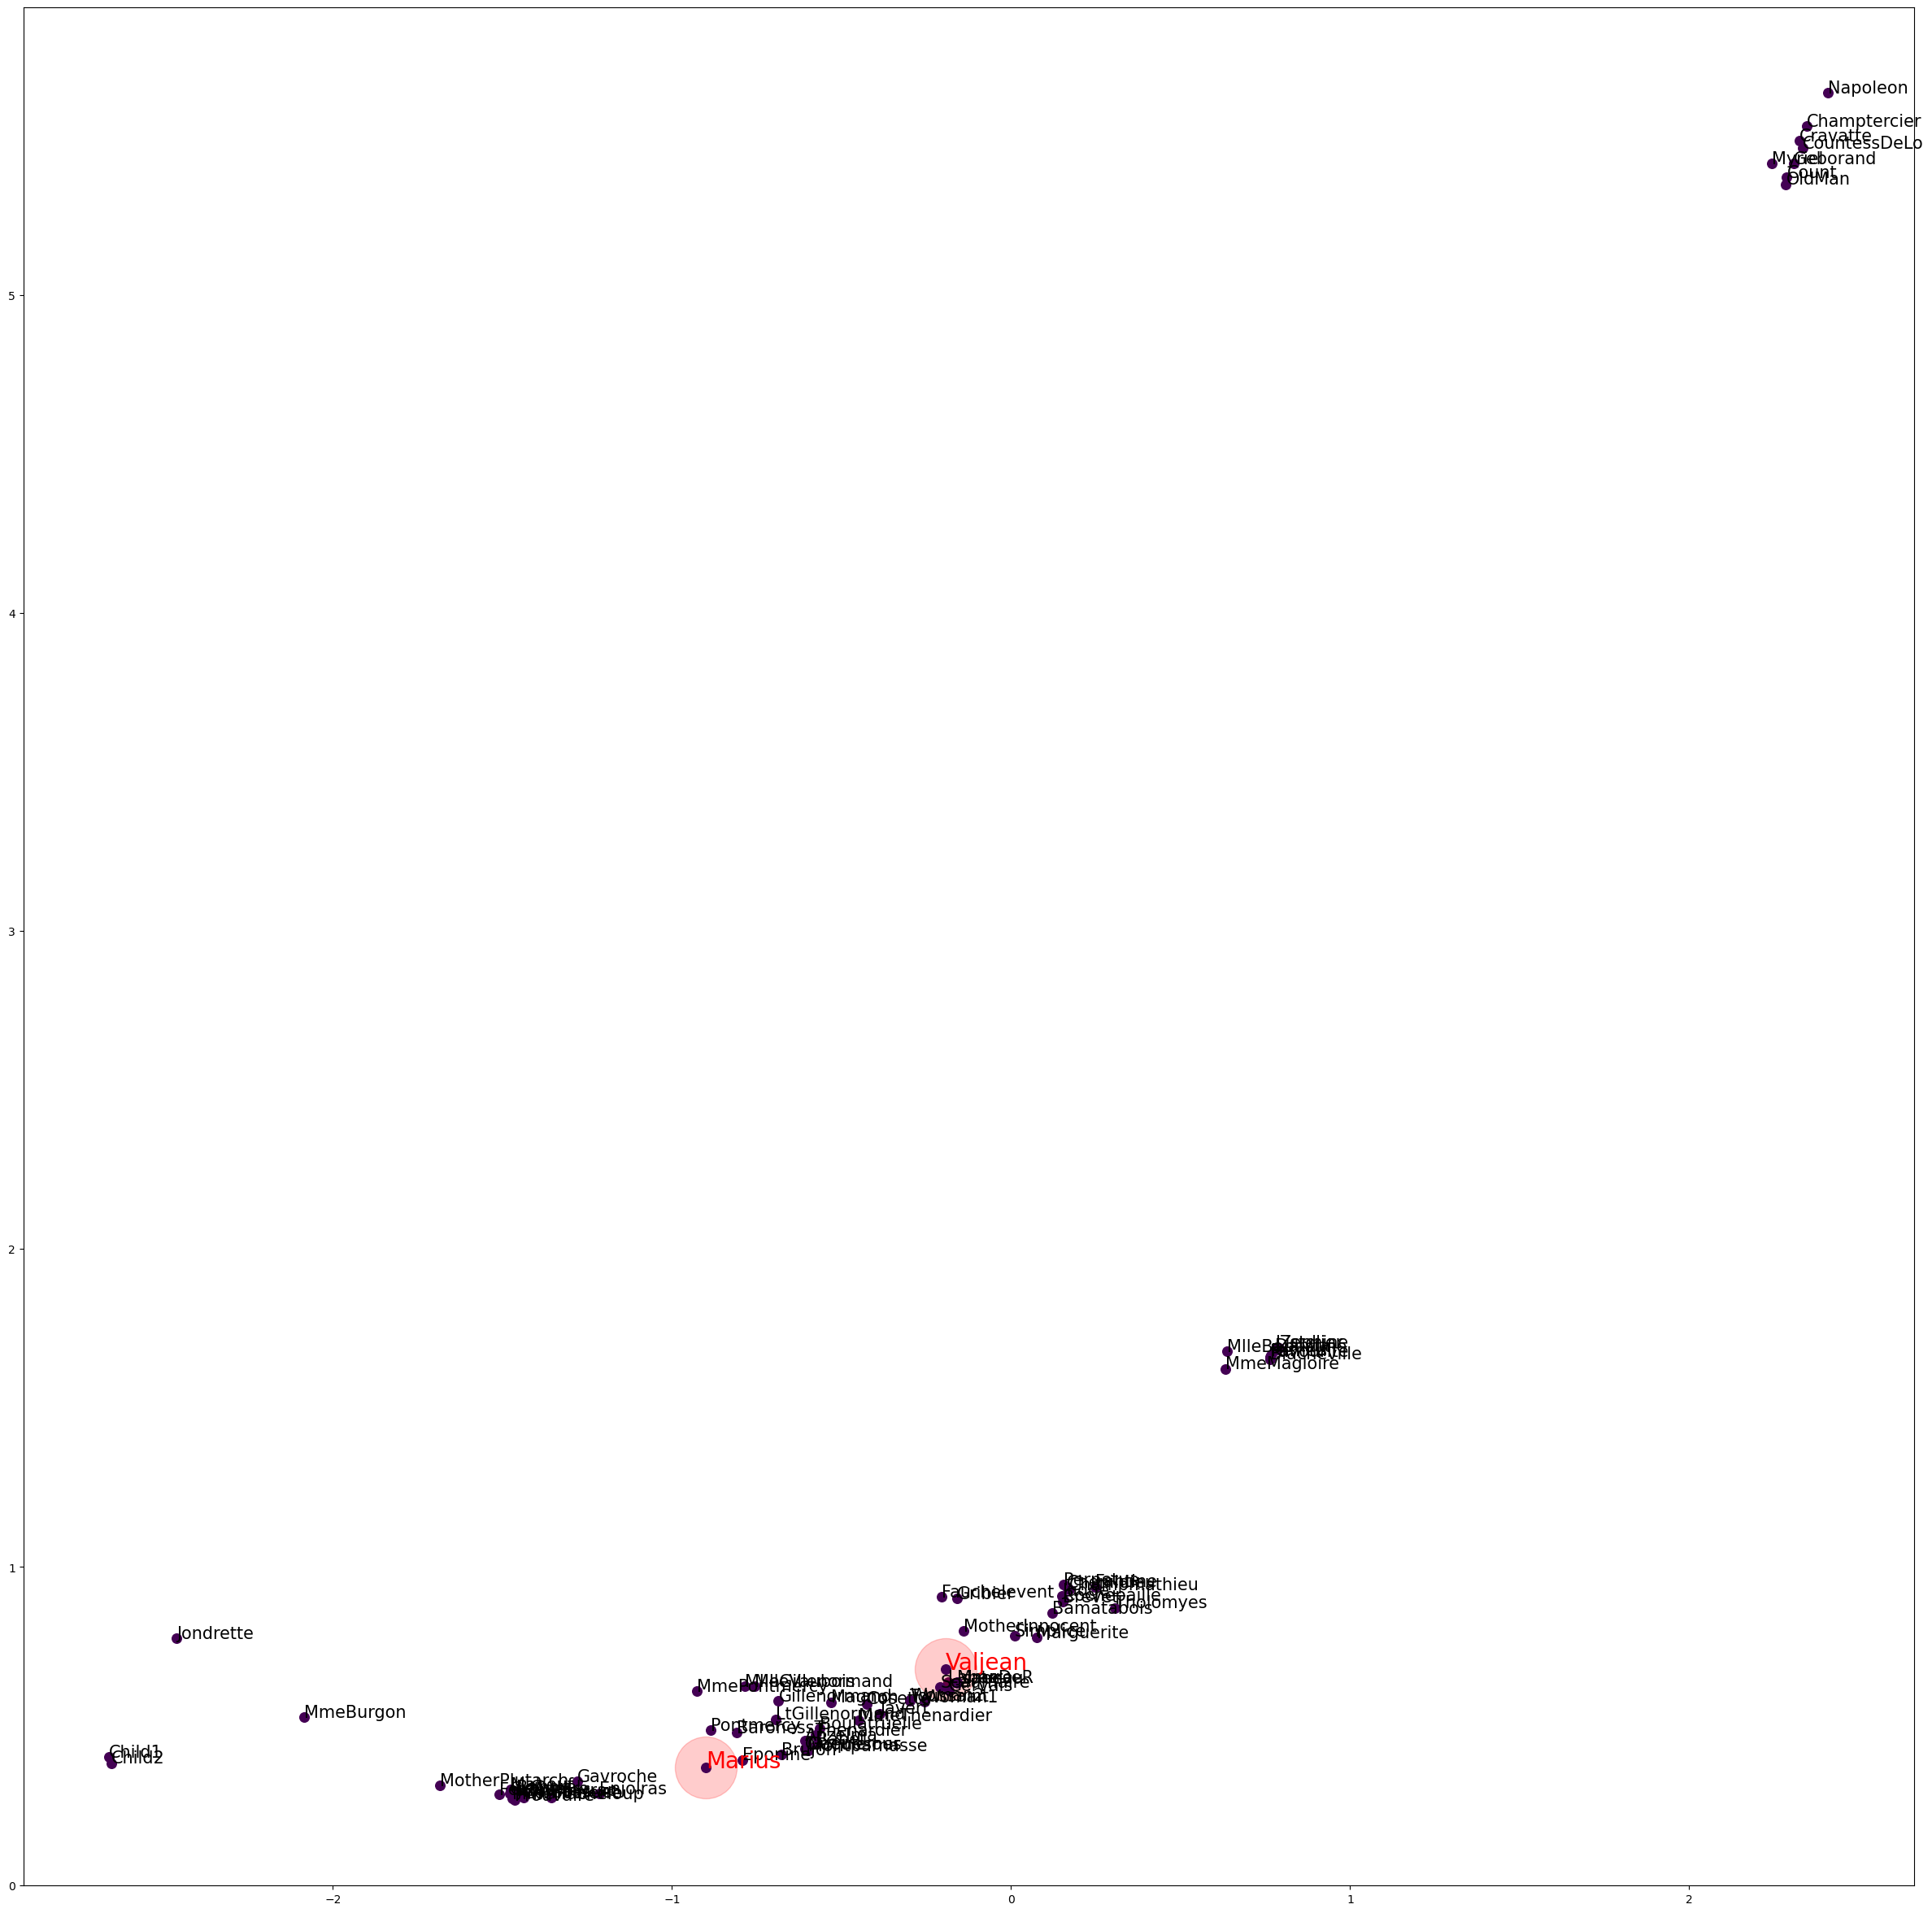

In [ ]:
dwlesmis.draw_embedded_vector(vec,node_annotation=node_annotation,ATTENTION_NODE_LIST=ATTENTION_NODE_LIST)

In [ ]:
#vecをkmeansでクラスタリング

pred = dwlesmis.clustering(vec, N_CLUSTER, METHOD)
    

In [ ]:


#pred = SpectralClustering(n_clusters=N_CLUSTER, affinity='nearest_neighbors', n_init=100).fit_predict(vec)
   


In [ ]:
colors = []
for i in pred:
    if i == 0:
        colors.append("red")
    elif i == 1:
        colors.append("blue")
    elif i == 2:
        colors.append("green")
    elif i == 3:
        colors.append("teal")
    elif i == 4:
        colors.append("purple")
    elif i == 5:
        colors.append("orange")
    elif i == 6:
        colors.append("pink")
    elif i == 7:
        colors.append("brown")
    elif i == 8:
        colors.append("gray")
    elif i == 9:
        colors.append("black")
    else:
        colors.append("white")


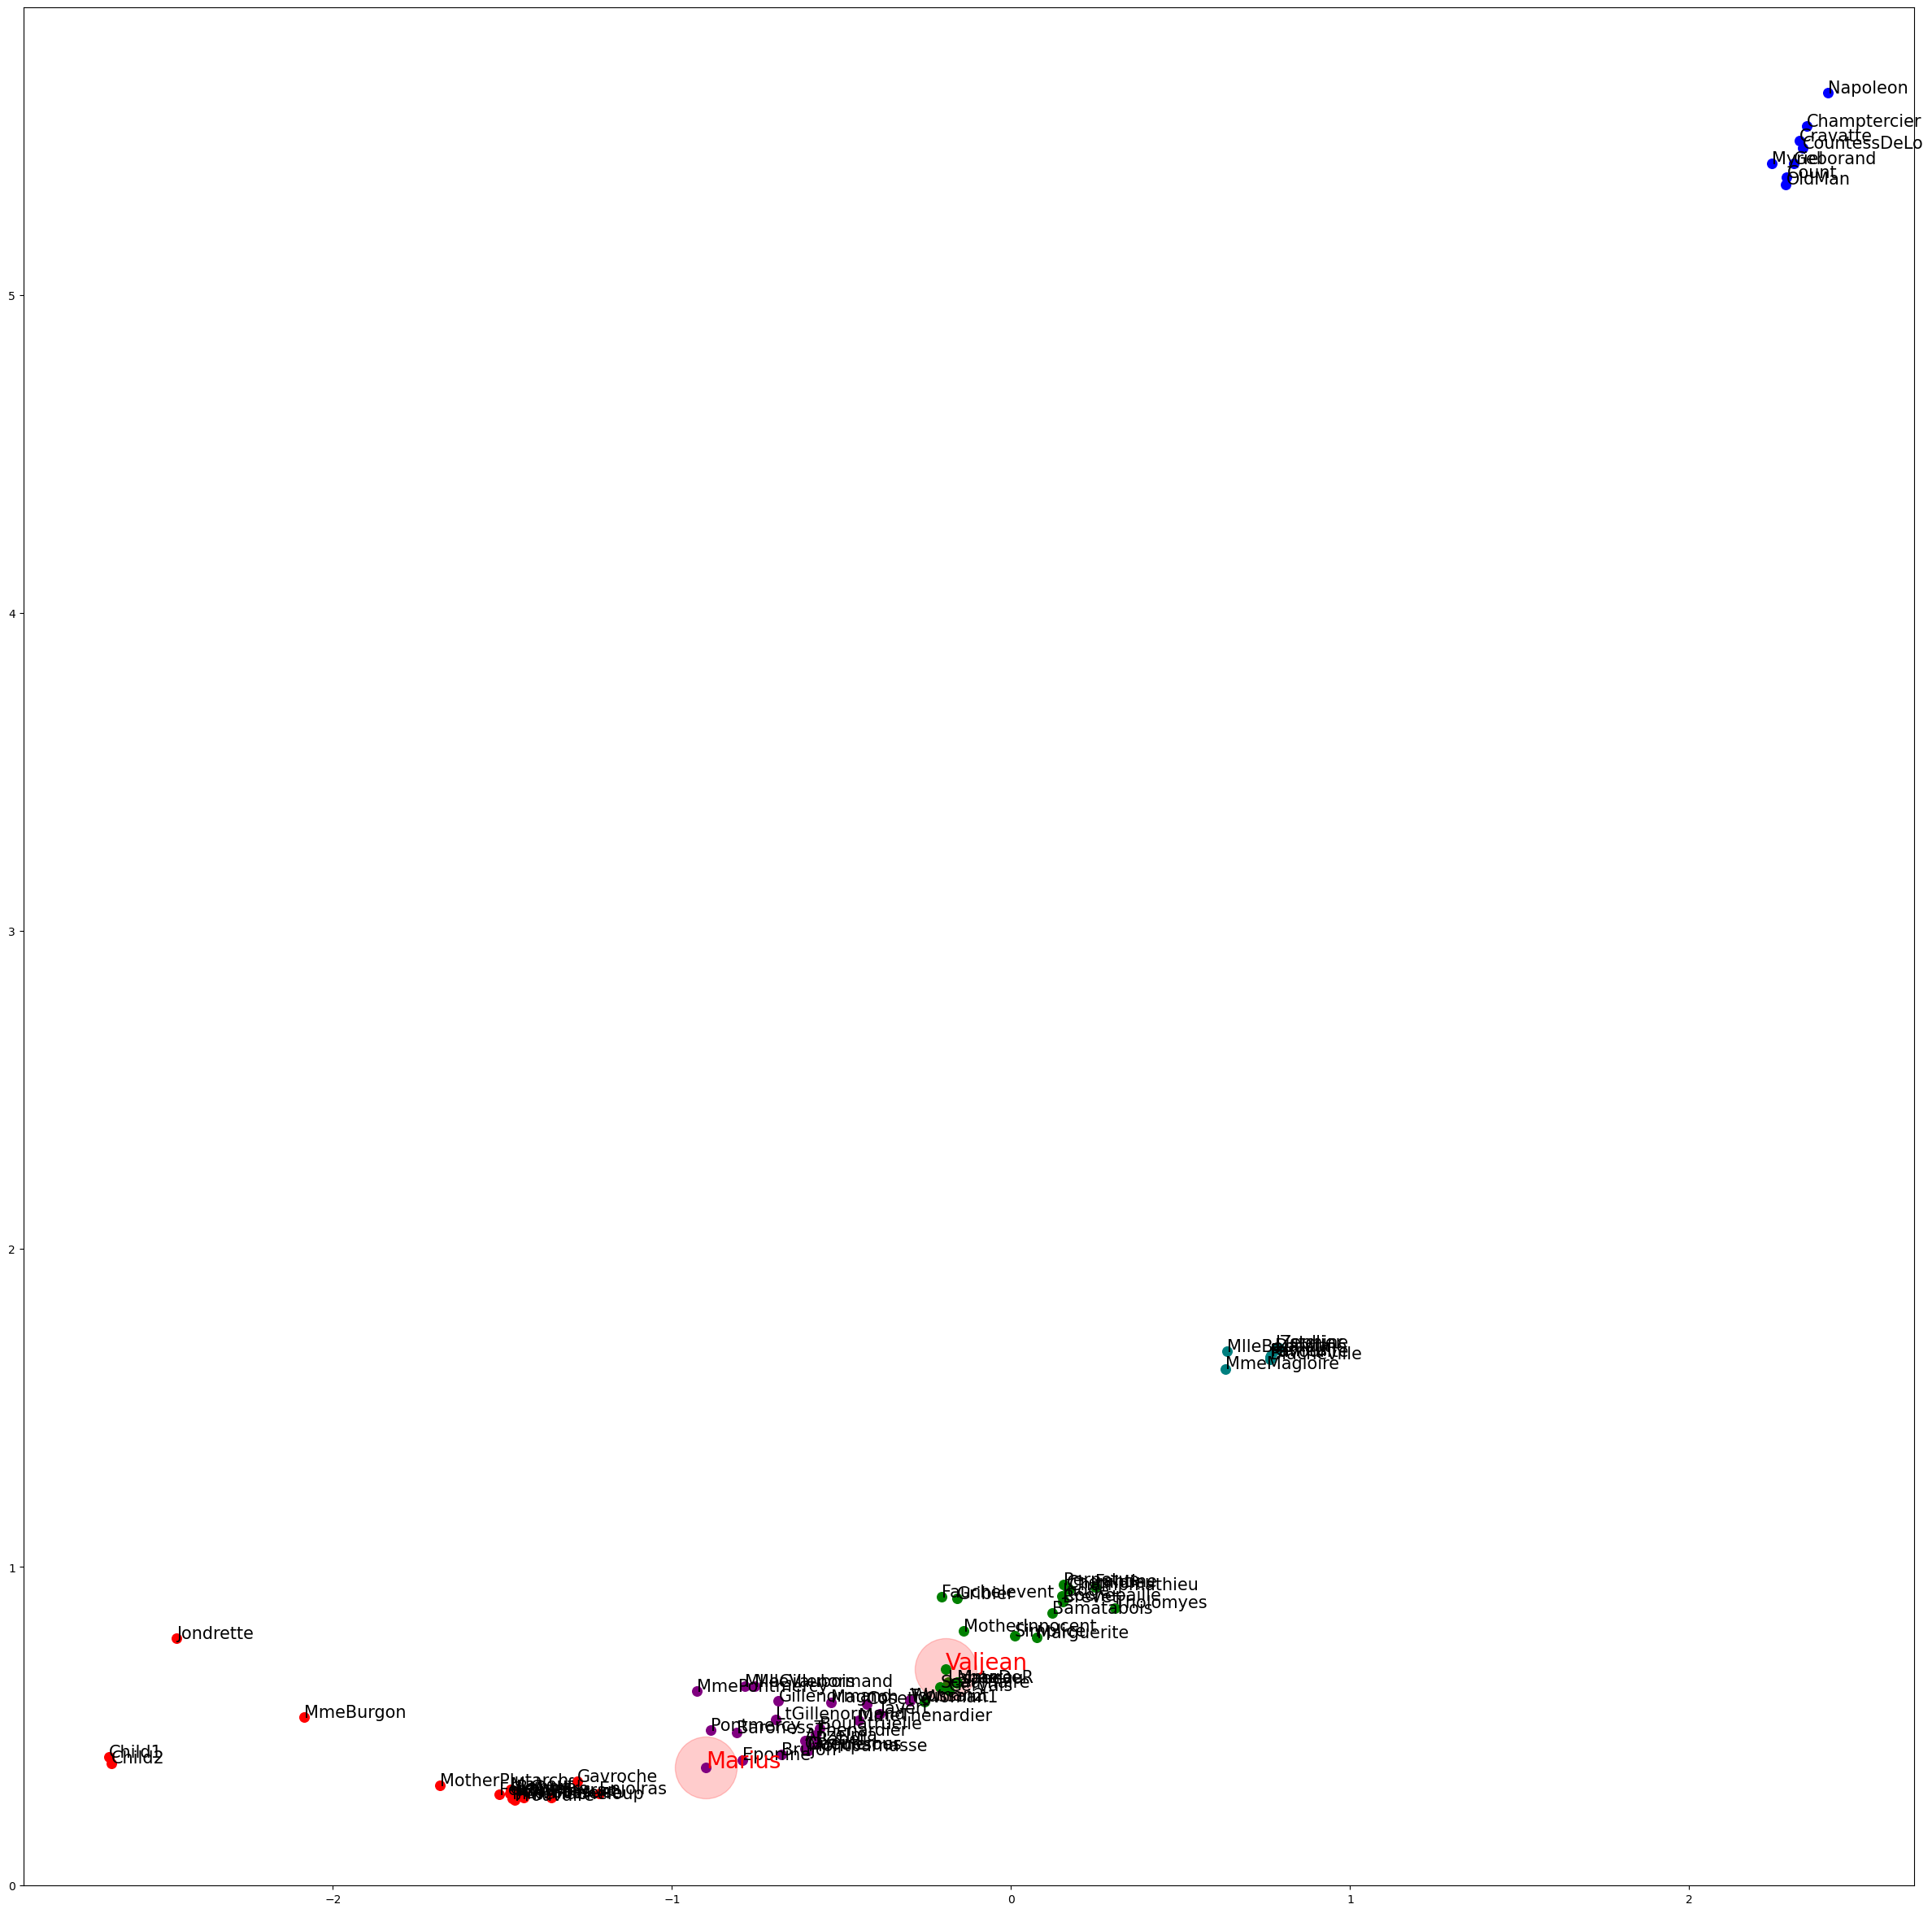

In [ ]:
dwlesmis.draw_embedded_vector(vec,colorlist=colors,node_annotation=node_annotation,ATTENTION_NODE_LIST=ATTENTION_NODE_LIST)

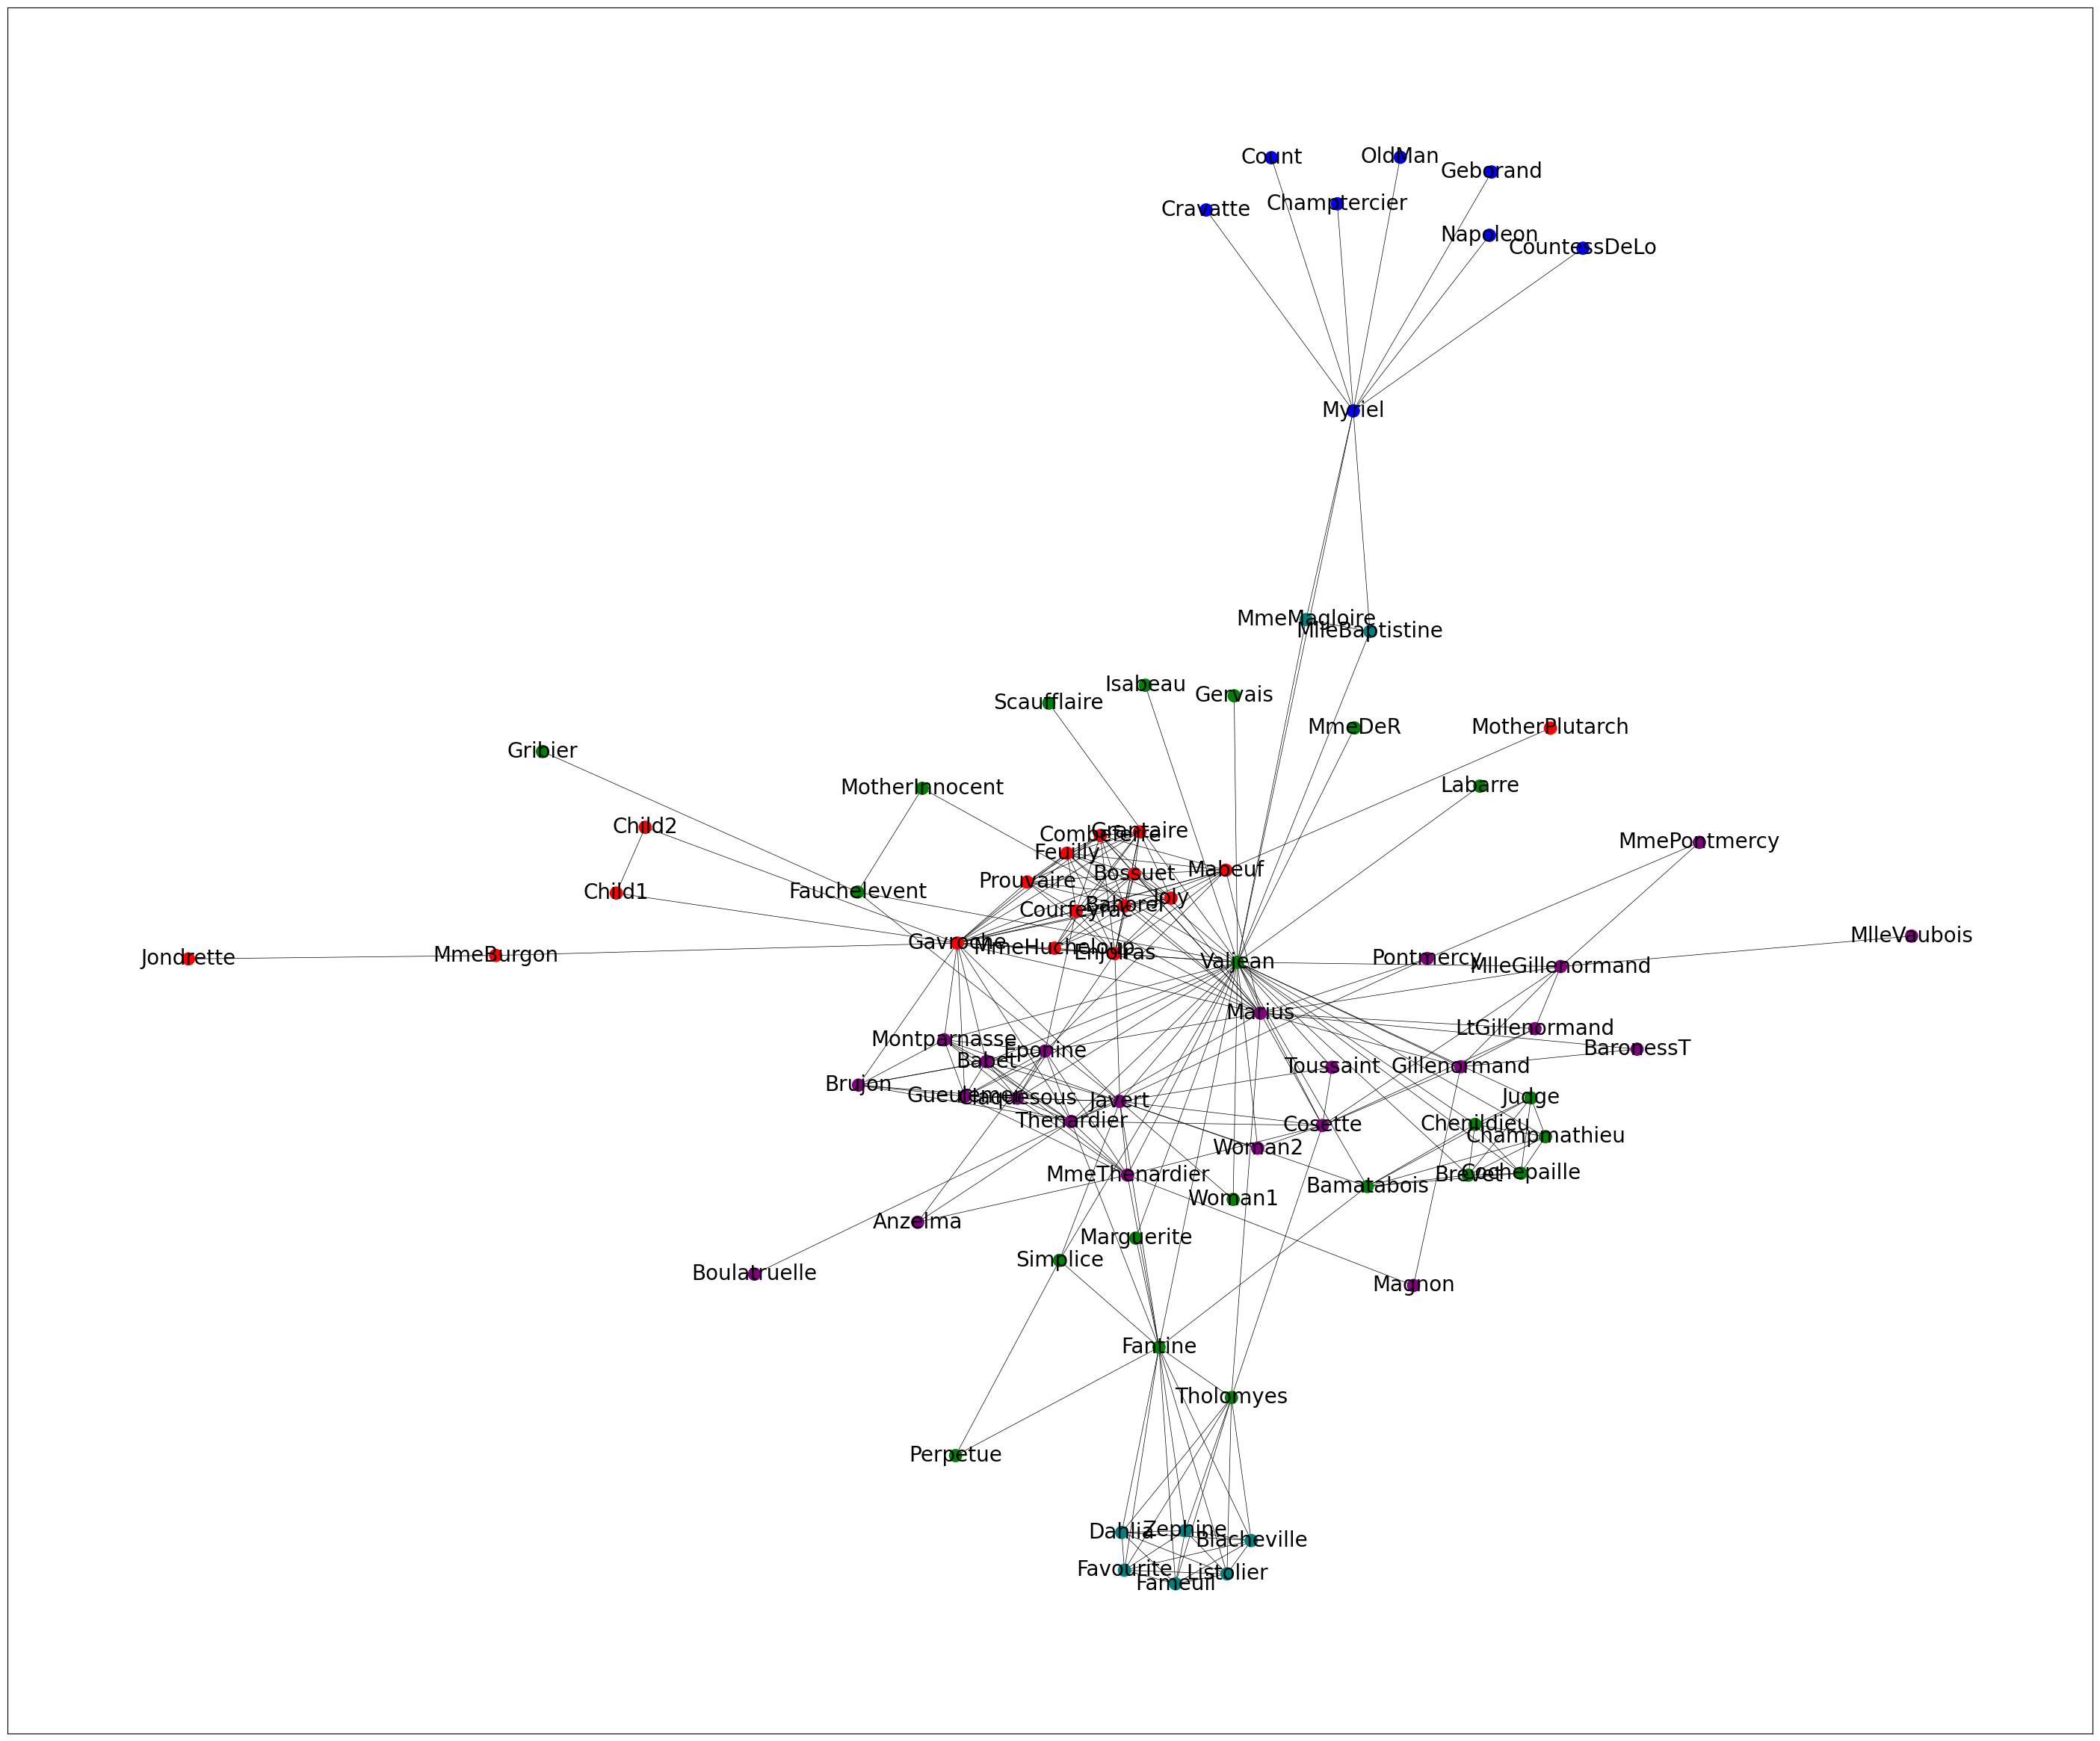

In [ ]:
dwlesmis.draw_network(INPUT, True, colors)

In [ ]:
lof = dwlesmis.culc_lof(vec, k = 4)

In [ ]:
#node_annotationとlofの値を辞書型で結合
node_lof = dict(zip(node_annotation,lof))



In [ ]:
node_lof["Valjean"]

1.1901819072510054